<a href="https://colab.research.google.com/github/DAGP1145/MineriaDeDatos2/blob/main/Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Acerca del Conjunto de Datos

Con la creciente competencia en el mercado minorista global, las empresas deben basarse en los datos para comprender mejor a sus clientes, productos y el rendimiento regional.

Este conjunto de datos contiene registros de ventas transaccionales de una supertienda global. Proporciona información detallada sobre pedidos, clientes, productos, envíos y rendimiento financiero.

El conjunto de datos puede utilizarse para explorar diversas cuestiones empresariales como:

1.  **¿Qué mercados y regiones generan más ventas y beneficios?**
2.  **¿Qué categorías o subcategorías de productos rinden mejor?**
3.  **¿Cómo afectan los descuentos a la rentabilidad?**
4.  **¿Qué modos y prioridades de envío se utilizan más comúnmente?**
5.  **¿Qué segmentos de clientes aportan más ingresos?**

Este conjunto de datos es adecuado para:

*   Análisis Exploratorio de Datos (EDA)
*   Paneles de control de Inteligencia Empresarial
*   Analítica de clientes y producto
*   Modelado de almacén de datos y esquemas estrellas

No dudes en explorar los datos y generar información que pueda ayudar a una empresa minorista a optimizar la oferta de productos, las estrategias de precios y las operaciones regionales.

# Descripción de las Columnas (para el Dataset de Supertienda)

A continuación, se detalla la descripción de cada columna en el dataset:

*   **`order_id`**: Identificador único para cada pedido.
*   **`order_date`**: Fecha en la que se realizó el pedido.
*   **`ship_date`**: Fecha en que se envió el pedido.
*   **`ship_mode`**: Método de envío elegido por el cliente (Clase Estándar, Segunda Clase, etc.).
*   **`customer_name`**: Nombre del cliente que realizó el pedido.
*   **`segment`**: Clasificación de segmentos de clientes (Consumidor, Corporativo, Oficina en Central).
*   **`state`**: Estado o provincia del cliente.
*   **`country`**: País donde se encuentra el cliente.
*   **`market`**: Agrupación de mercado que representa un área geográfica más amplia (por ejemplo, APAC, UE, EE. UU.).
*   **`region`**: Clasificación regional dentro de cada mercado.
*   **`product_id`**: Identificador único para cada producto.
*   **`category`**: Categoría de producto de alto nivel.
*   **`sub_category`**: Clasificación detallada del producto.
*   **`product_name`**: Nombre del producto.
*   **`sales`**: Valor total de ventas para la línea de pedidos.
*   **`quantity`**: Número de unidades compradas.
*   **`discount`**: Descuento aplicado al pedido.
*   **`profit`**: Ganancias o pérdidas generadas por la transacción.
*   **`shipping_cost`**: Coste incurrido para enviar el pedido.
*   **`order_priority`**: Nivel de prioridad asignado a la orden.
*   **`year`**: Año en que se realizó el pedido.

# Importación de librerías

In [4]:
import pandas as pd # Estructura y manipulación de datos
import numpy as np #Programación vectorial

## Configuración de Kaggle

In [5]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Carga de los datos



In [6]:
# Set the path to the file you'd like to load
file_path = "SuperStoreOrders - SuperStoreOrders.csv"
# Esta variable se inicializa vacía. En el contexto de kagglehub.load_dataset,
# este file_path se usaría para especificar un archivo particular dentro de un
# dataset de Kaggle si el dataset contiene múltiples archivos y se desea cargar solo uno.
# Si se deja vacío, kagglehub intentará cargar el archivo principal o predeterminado.

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "thuandao/superstore-sales-analytics",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

100%|██████████| 10.3M/10.3M [00:00<00:00, 11.2MB/s]


# Analisis General

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [8]:
print("Primeras 5 filas del DataFrame:")
display(df.head())

Primeras 5 filas del DataFrame:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [9]:
print("\nInformación general del DataFrame (tipos de datos, no nulos):")
df.info()


Información general del DataFrame (tipos de datos, no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount     

In [10]:
print("\nEstadísticas descriptivas para columnas numéricas:")
df.describe().round(2)


Estadísticas descriptivas para columnas numéricas:


,quantity,discount,profit,shipping_cost,year
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,3.48,0.14,28.64,26.38,2012.78
std,2.28,0.21,174.42,57.30,1.10
min,1.00,0.00,-6599.98,0.00,2011.00
25%,2.00,0.00,0.00,2.61,2012.00
50%,3.00,0.00,9.24,7.79,2013.00
75%,5.00,0.20,36.81,24.45,2014.00
max,14.00,0.85,8399.98,933.57,2014.00


In [11]:
print("\nConteo de valores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))


Conteo de valores nulos por columna:


,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [12]:
print("\nForma del DataFrame (filas, columnas):")
print(df.shape)


Forma del DataFrame (filas, columnas):
(51290, 21)


# Transformaciòn Inicial

In [13]:
print("\nRealizando conversiones de tipo de datos para 'sales', 'order_date' y 'ship_date' en un nuevo DataFrame...")

df_borrador = df.copy()

# Convertir 'sales' a numérico, manejando posibles errores
df_borrador['sales'] = pd.to_numeric(df_borrador['sales'], errors='coerce')

# Convertir 'order_date' y 'ship_date' a formato datetime ademàs de ajustarlo al formato del orden en que esta en el dataset
df_borrador['order_date'] = pd.to_datetime(df_borrador['order_date'], format='%d/%m/%Y')
df_borrador['ship_date'] = pd.to_datetime(df_borrador['ship_date'], format='%d/%m/%Y')

print("Conversiones completadas en 'df_transformed'. Verificando los tipos de datos actualizados:")
df_borrador.info()


Realizando conversiones de tipo de datos para 'sales', 'order_date' y 'ship_date' en un nuevo DataFrame...
Conversiones completadas en 'df_transformed'. Verificando los tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category   

In [14]:
print("\nConteo de valores nulos por columna:")
display(df_borrador.isnull().sum().sort_values(ascending=False))


Conteo de valores nulos por columna:


,0
sales,2630
order_date,0
ship_date,0
ship_mode,0
order_id,0
customer_name,0
segment,0
country,0
state,0
region,0


In [15]:
print("\nEstadísticas descriptivas para columnas numéricas:")
#Se especifico porque tomaba la columna fecha
df_borrador[['quantity',	'discount',	'profit',	'shipping_cost',	'year', 'sales']].describe().round(2)


Estadísticas descriptivas para columnas numéricas:


,quantity,discount,profit,shipping_cost,year,sales
count,51290.00,51290.00,51290.00,51290.00,51290.00,48660.00
mean,3.48,0.14,28.64,26.38,2012.78,161.02
std,2.28,0.21,174.42,57.30,1.10,201.09
min,1.00,0.00,-6599.98,0.00,2011.00,0.00
25%,2.00,0.00,0.00,2.61,2012.00,29.00
50%,3.00,0.00,9.24,7.79,2013.00,77.00
75%,5.00,0.20,36.81,24.45,2014.00,208.00
max,14.00,0.85,8399.98,933.57,2014.00,999.00


# Analisis Detallado

### Valores Nulos en la Columna 'sales'

In [16]:
print("Mostrando las filas donde la columna 'sales' es nula (NaN) en `df_borrador`:")
null_sales_rows = df_borrador[df_borrador['sales'].isnull()]

if not null_sales_rows.empty:
    print(f"Se encontraron {len(null_sales_rows)} filas con valores nulos en 'sales'.")
    print("Mostrando las primeras 10 filas con 'sales' nulas para su inspección:")
    display(null_sales_rows.head(10))
else:
    print("No se encontraron filas con valores nulos en la columna 'sales'.")

Mostrando las filas donde la columna 'sales' es nula (NaN) en `df_borrador`:
Se encontraron 2630 filas con valores nulos en 'sales'.
Mostrando las primeras 10 filas con 'sales' nulas para su inspección:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",NaN,6,0.0,609.8400,109.13,Medium,2011
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",NaN,8,0.0,999.3600,191.20,Medium,2011
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,NaN,9,0.0,746.4078,258.99,High,2011
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",NaN,6,0.0,49.5000,349.87,High,2011
84,IN-2011-19330,2011-01-08,2011-01-12,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,TEC-MA-10002468,Technology,Machines,"Panasonic Inkjet, White",NaN,7,0.0,260.8200,275.52,Medium,2011
100,IN-2011-61302,2011-01-10,2011-01-11,First Class,Dan Lawera,Consumer,Queensland,Australia,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",NaN,5,0.1,511.0950,665.27,Medium,2011
125,ES-2011-5158390,2011-01-11,2011-01-11,Same Day,Roy Collins,Consumer,England,United Kingdom,EU,North,FUR-CH-10004255,Furniture,Chairs,"SAFCO Executive Leather Armchair, Red",NaN,3,0.0,13.7700,178.98,Medium,2011
126,US-2011-163874,2011-01-11,2011-01-12,First Class,Philip Fox,Consumer,México,Mexico,LATAM,North,OFF-ST-10003741,Office Supplies,Storage,"Smead Lockers, Blue",NaN,10,0.0,238.0000,103.84,Medium,2011
163,EG-2011-4270,2011-01-13,2011-01-18,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,TEC-HP -10001574,Technology,Copiers,"HP Fax Machine, Laser",NaN,4,0.0,479.8800,55.62,Medium,2011
173,CA-2011-157147,2011-01-14,2011-01-19,Standard Class,Brian Dahlen,Consumer,California,United States,US,West,OFF-ST-10000078,Office Supplies,Storage,Tennsco 6- and 18-Compartment Lockers,NaN,5,0.0,238.6530,187.65,High,2011


### Valores `sales` en `df` para `order_id`s con `sales` Nulos en `df_borrador`

In [17]:
print("Consultando el dataset original 'df' para los 'sales' de los 'order_id's con valores nulos en 'df_borrador':")

order_ids_with_null_sales = null_sales_rows['order_id'].tolist()

# Filtrar el DataFrame original 'df' por estos order_ids y mostrar la columna 'sales'
original_sales_for_nulls = df[df['order_id'].isin(order_ids_with_null_sales)][['order_id', 'sales']]
display(original_sales_for_nulls.head(10))

Consultando el dataset original 'df' para los 'sales' de los 'order_id's con valores nulos en 'df_borrador':


,order_id,sales
27,MX-2011-111255,"1,648"
31,MX-2011-111255,149
43,MX-2011-109267,"3,029"
58,CA-2011-167199,"2,574"
59,CA-2011-167199,610
60,CA-2011-167199,392
67,CA-2011-167199,756
78,CA-2011-167199,31
79,CA-2011-167199,7
81,CA-2011-167199,5


In [18]:
print("\nRealizando conversiones de tipo de datos para 'sales'")

# Limpiar la columna 'sales' eliminando comas antes de convertir a numérico
df_borrador['sales'] = df['sales'].astype(str).str.replace(',', '', regex=False)

# Convertir 'sales' a numérico, manejando posibles errores
df_borrador['sales'] = pd.to_numeric(df_borrador['sales'], errors='coerce')

print("Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:")
df_borrador['sales'].info()
print("\nConteo de valores nulos por columna:")
display(df_borrador['sales'].isnull().sum())


Realizando conversiones de tipo de datos para 'sales'
Conversiones completadas en 'df_borrador'. Verificando los tipos de datos actualizados:
<class 'pandas.core.series.Series'>
RangeIndex: 51290 entries, 0 to 51289
Series name: sales
Non-Null Count  Dtype
--------------  -----
51290 non-null  int64
dtypes: int64(1)
memory usage: 400.8 KB

Conteo de valores nulos por columna:


np.int64(0)

### Profit Negativos

In [19]:
print("Filtrando `df_borrador` para encontrar transacciones con 'profit' negativo...")
negative_profit_df = df_borrador[df_borrador['profit'] < 0]

if not negative_profit_df.empty:
    print(f"\n Se encontraron {len(negative_profit_df)} filas con 'profit' negativo.\n")
    print("\n Estadísticas descriptivas para las columnas relevantes en transacciones con profit negativo: \n")
    display(negative_profit_df[['sales', 'quantity', 'discount', 'shipping_cost', 'profit']].describe().round(2))
else:
    print("No se encontraron filas con 'profit' negativo.")

Filtrando `df_borrador` para encontrar transacciones con 'profit' negativo...

 Se encontraron 12543 filas con 'profit' negativo.


 Estadísticas descriptivas para las columnas relevantes en transacciones con profit negativo: 



,sales,quantity,discount,shipping_cost,profit
count,12543.00,12543.00,12543.00,12543.00,12543.00
mean,198.23,3.43,0.45,21.16,-73.38
std,422.63,2.28,0.19,46.69,186.22
min,0.00,1.00,0.00,0.01,-6599.98
25%,21.00,2.00,0.40,1.85,-65.34
50%,65.00,3.00,0.47,5.92,-21.20
75%,207.00,5.00,0.60,19.92,-6.90
max,22638.00,14.00,0.85,910.16,-0.00


In [20]:
# Calcular el precio original del producto (sin descuento) por unidad
# original_price_per_item = sales / (quantity * (1 - discount))
# Usamos np.where para manejar el caso donde discount es 1 y evitar división por cero.
# Si discount es 1, el 'sales' ya debería ser 0, y el precio original sería 0.
# Si sales no es 0 cuando discount es 1, esto indicaría un problema de datos,
# pero para el cálculo del precio original, si 1 - discount es 0, simplemente usamos sales/quantity.
df_borrador['precio_unidad'] = np.where(
    df_borrador['discount'] == 1,
    df_borrador['sales'] / df_borrador['quantity'],
    df_borrador['sales'] / (df_borrador['quantity'] * (1 - df_borrador['discount']))
)

In [21]:
# Calcular el costo unitario del producto, excluyendo el shipping_cost
# costo_unitario = (sales - profit - shipping_cost) / quantity
# Manejar división por cero si la cantidad es 0 (aunque generalmente la cantidad es > 0)
df_borrador['costo_unitario'] = np.where(
    df_borrador['quantity'] == 0,
    0, # O se podría manejar como NaN o un valor indicativo si la cantidad es cero
    (df_borrador['sales'] - df_borrador['profit'] - df_borrador['shipping_cost']) / df_borrador['quantity']
)

print("Primeras 5 filas con la columna 'costo_unitario' modificada (sin shipping_cost):")
display(df_borrador[['sales', 'profit', 'shipping_cost', 'quantity', 'costo_unitario']].head())

Primeras 5 filas con la columna 'costo_unitario' modificada (sin shipping_cost):


,sales,profit,shipping_cost,quantity,costo_unitario
0,408,106.140,35.46,2,133.200000
1,120,36.036,9.72,3,24.748000
2,66,29.640,8.17,4,7.047500
3,45,-26.055,4.82,3,22.078333
4,114,37.770,4.70,5,14.306000


In [22]:
# Calcular el margen unitario
df_borrador['margen_unitario'] = df_borrador['precio_unidad'] - df_borrador['costo_unitario']

print("Primeras 5 filas con las columnas 'precio_unidad', 'costo_unitario' y 'margen_unitario':")
display(df_borrador[['precio_unidad', 'costo_unitario', 'margen_unitario']].head())

Primeras 5 filas con las columnas 'precio_unidad', 'costo_unitario' y 'margen_unitario':


,precio_unidad,costo_unitario,margen_unitario
0,204.000000,133.200000,70.800000
1,44.444444,24.748000,19.696444
2,16.500000,7.047500,9.452500
3,30.000000,22.078333,7.921667
4,25.333333,14.306000,11.027333


In [23]:
df_borrador.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,204.000000,133.200000,70.800000
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,44.444444,24.748000,19.696444
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,16.500000,7.047500,9.452500
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,30.000000,22.078333,7.921667
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,25.333333,14.306000,11.027333


# Graficos

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

### Top categorias por Ventas dentro de Cada Categoría

A continuación, generaremos un gráfico para cada una de las categorías principales (`category`), mostrando las subcategorias que más ganancias han generado dentro de esa categoría específica.

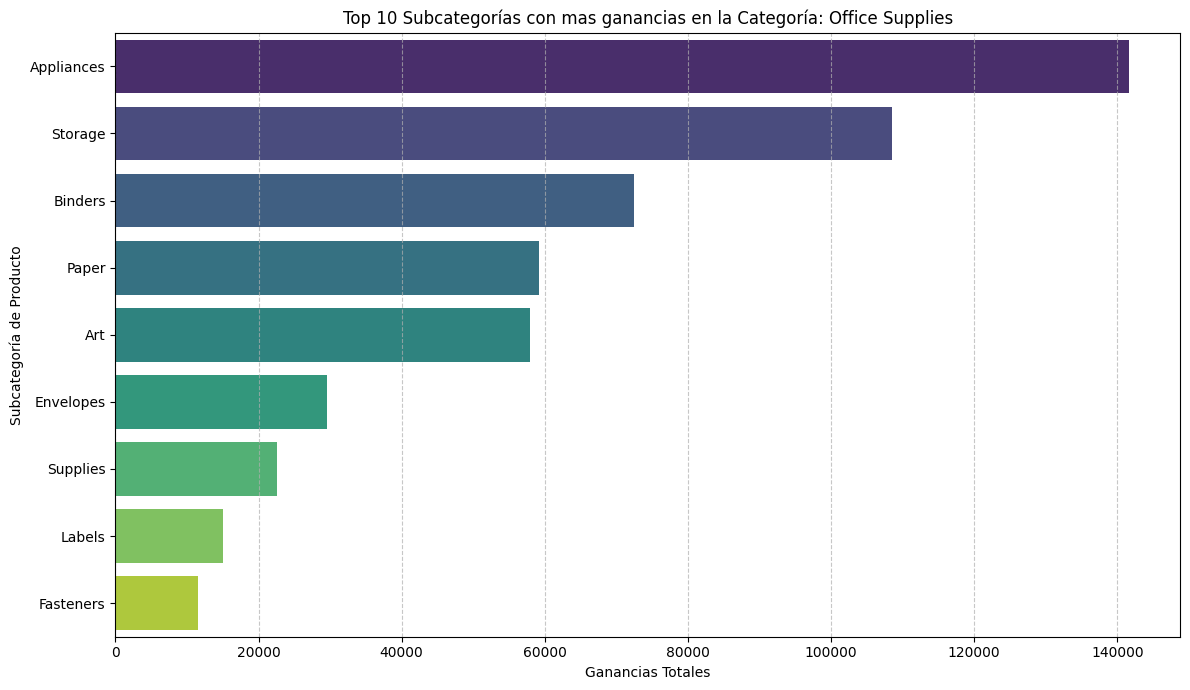


------------------------------



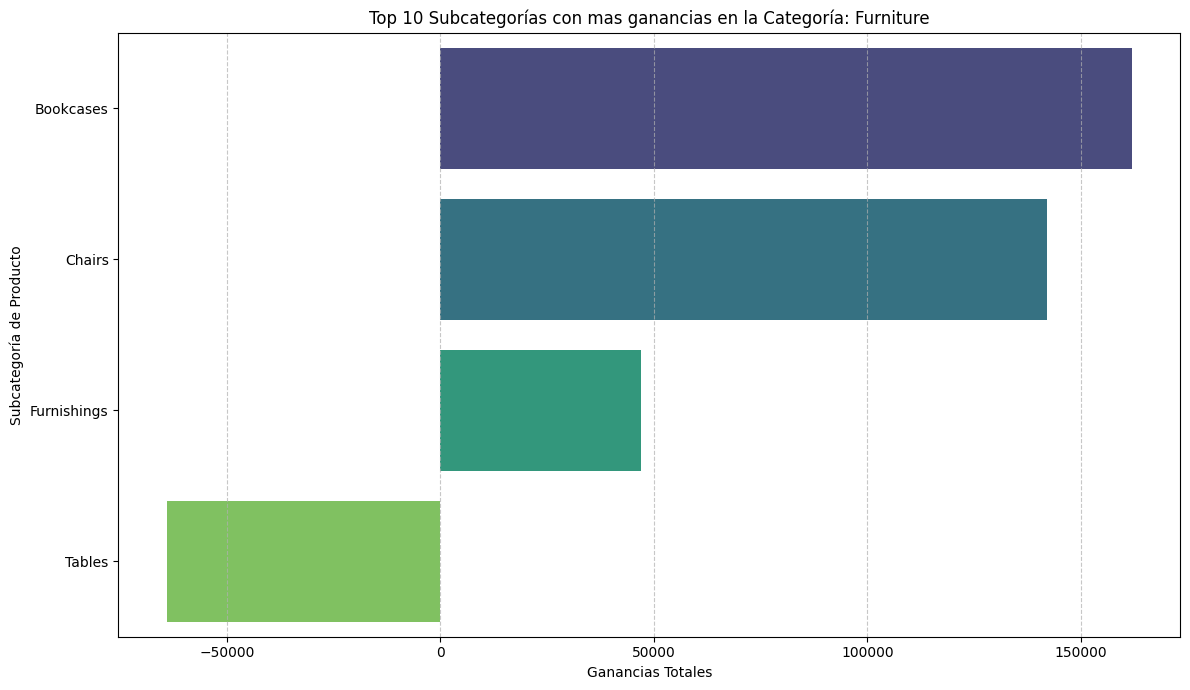


------------------------------



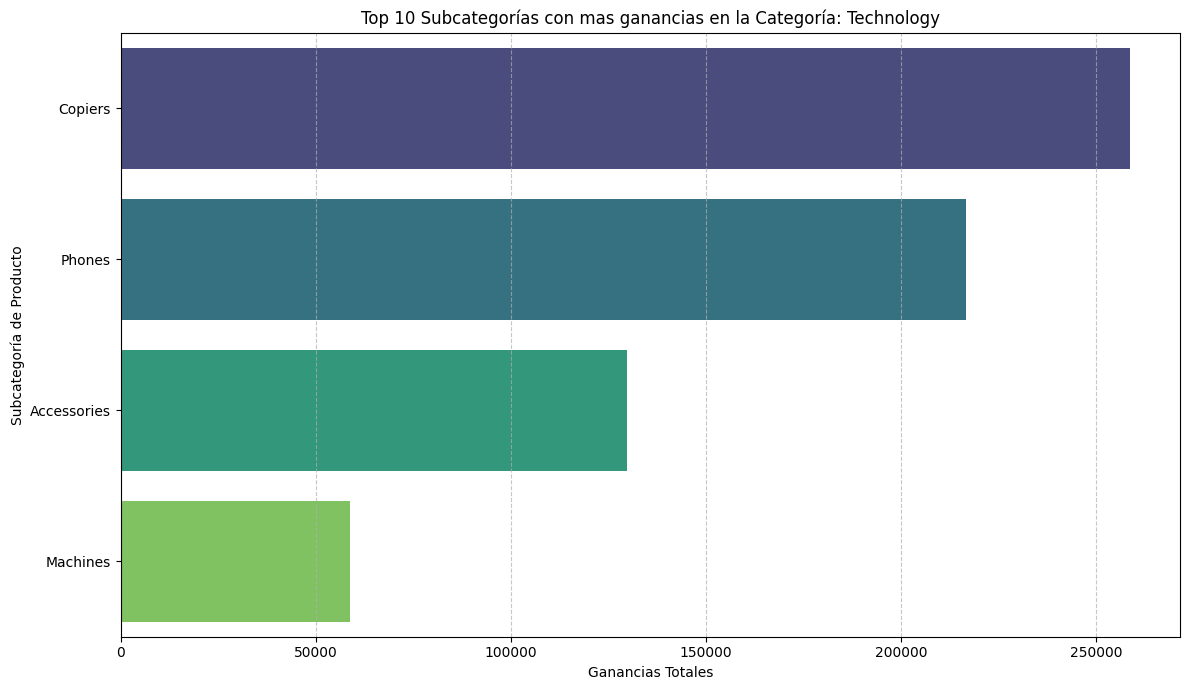


------------------------------



In [25]:
unique_categories = df_borrador['category'].unique()

for category in unique_categories:
    # Filtrar el DataFrame para la categoría actual
    df_category = df_borrador[df_borrador['category'] == category]

    # Agrupar por sub_category y sumar las ventas dentro de esta categoría
    top_10_subcategories_in_category = df_category.groupby('sub_category')['profit'].sum().nlargest(10).reset_index()

    if not top_10_subcategories_in_category.empty:
        # Crear el gráfico de barras
        plt.figure(figsize=(12, 7))
        sns.barplot(x='profit', y='sub_category', data=top_10_subcategories_in_category, palette='viridis', hue='sub_category', legend=False)
        plt.title(f'Top 10 Subcategorías con mas ganancias en la Categoría: {category}')
        plt.xlabel('Ganancias Totales')
        plt.ylabel('Subcategoría de Producto')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        plt.close() # Close the plot to prevent them from stacking
        print("\n" + "---"*10 + "\n") # Add a visible separator between plots
    else:
        print(f"No hay datos de ventas para la categoría: {category}")

### Ganancias por Subcategoría de Producto

Finalmente, visualizaremos las ganancias por subcategoría para identificar las subcategorías de productos más vendidas.

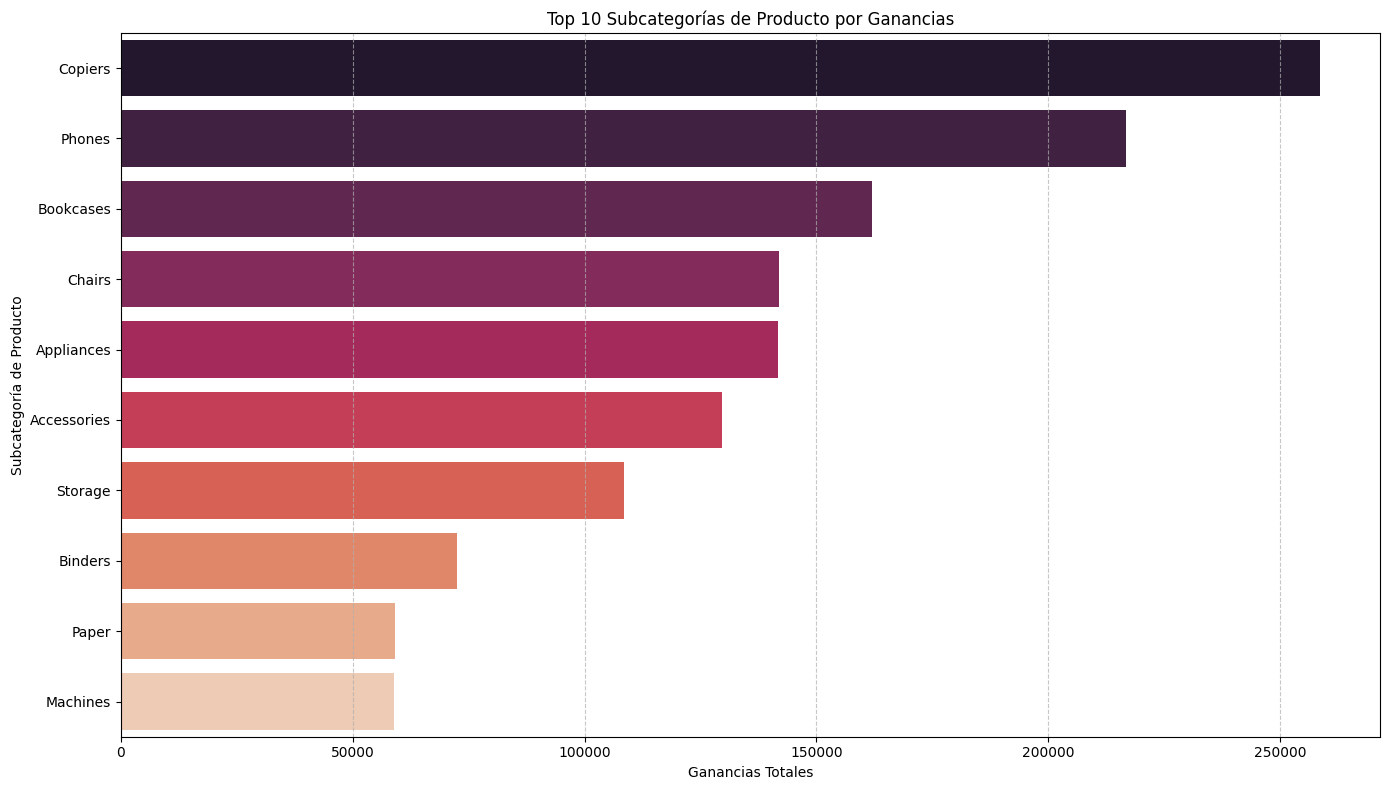

In [26]:
# Calcular las ventas totales por subcategoría de producto y tomar las 10 principales para una mejor visualización
sales_by_subcategory = df_borrador.groupby('sub_category')['profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='profit', y='sub_category', data=sales_by_subcategory, palette='rocket', hue='sub_category', legend=False)
plt.title('Top 10 Subcategorías de Producto por Ganancias')
plt.xlabel('Ganancias Totales')
plt.ylabel('Subcategoría de Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ganancias Percibidas por Producto (Top 10)

Ahora, vamos a identificar y visualizar los 10 productos que han generado mayores ganancias.

In [27]:
# Agrupar por nombre de producto y sumar las ganancias
top_10_profitable_products = df_borrador.groupby('product_name')['profit'].sum().nlargest(10).reset_index()
top_10_profitable_products.columns = ['product_name', 'total_profit']

print("Top 10 Productos Más Rentables:")
display(top_10_profitable_products)

Top 10 Productos Más Rentables:


,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,"Cisco Smart Phone, Full Size",17238.5206
2,"Motorola Smart Phone, Full Size",17027.1130
3,"Hoover Stove, Red",11807.9690
4,"Sauder Classic Bookcase, Traditional",10672.0730
5,"Harbour Creations Executive Leather Armchair, ...",10427.3260
6,"Nokia Smart Phone, Full Size",9938.1955
7,"Cisco Smart Phone, with Caller ID",9786.6408
8,"Nokia Smart Phone, with Caller ID",9465.3257
9,"Belkin Router, USB",8955.0180


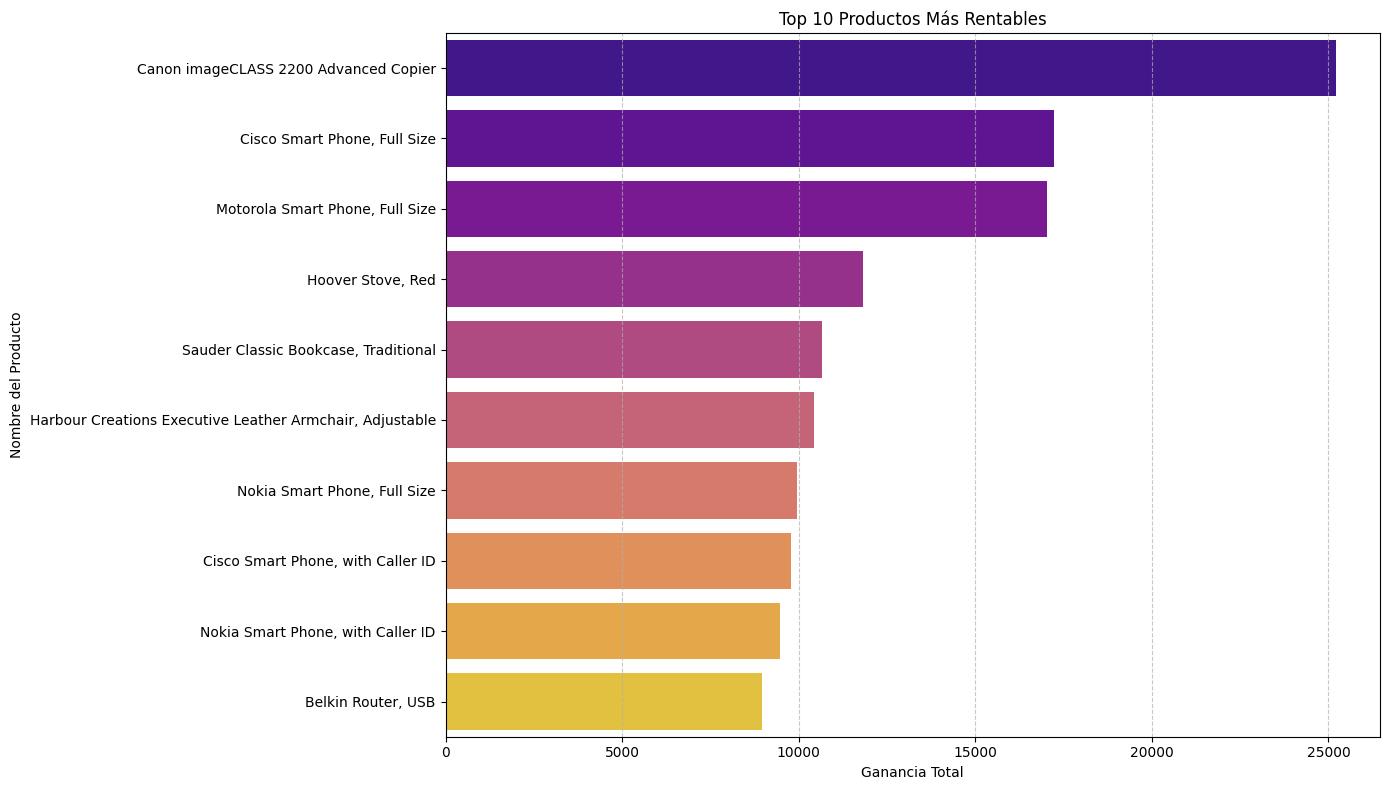

In [28]:
plt.figure(figsize=(14, 8))
sns.barplot(x='total_profit', y='product_name', data=top_10_profitable_products, palette='plasma', hue='product_name', legend=False)
plt.title('Top 10 Productos Más Rentables')
plt.xlabel('Ganancia Total')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Frecuencia de los 10 Productos Más Vendidos

Vamos a visualizar los 10 productos que se han vendido en mayor cantidad.

In [29]:
# Agrupar por nombre de producto y sumar la cantidad vendida
top_10_products = df_borrador.groupby('product_name')['quantity'].sum().nlargest(10).reset_index()
top_10_products.columns = ['product_name', 'total_quantity_sold']

print("Top 10 Productos Más Vendidos por Cantidad:")
display(top_10_products)

Top 10 Productos Más Vendidos por Cantidad:


,product_name,total_quantity_sold
0,Staples,876
1,"Cardinal Index Tab, Clear",337
2,"Eldon File Cart, Single Width",321
3,"Rogers File Cart, Single Width",262
4,"Sanford Pencil Sharpener, Water Color",259
5,"Stockwell Paper Clips, Assorted Sizes",253
6,"Avery Index Tab, Clear",252
7,"Ibico Index Tab, Clear",251
8,"Smead File Cart, Single Width",250
9,"Stanley Pencil Sharpener, Water Color",242


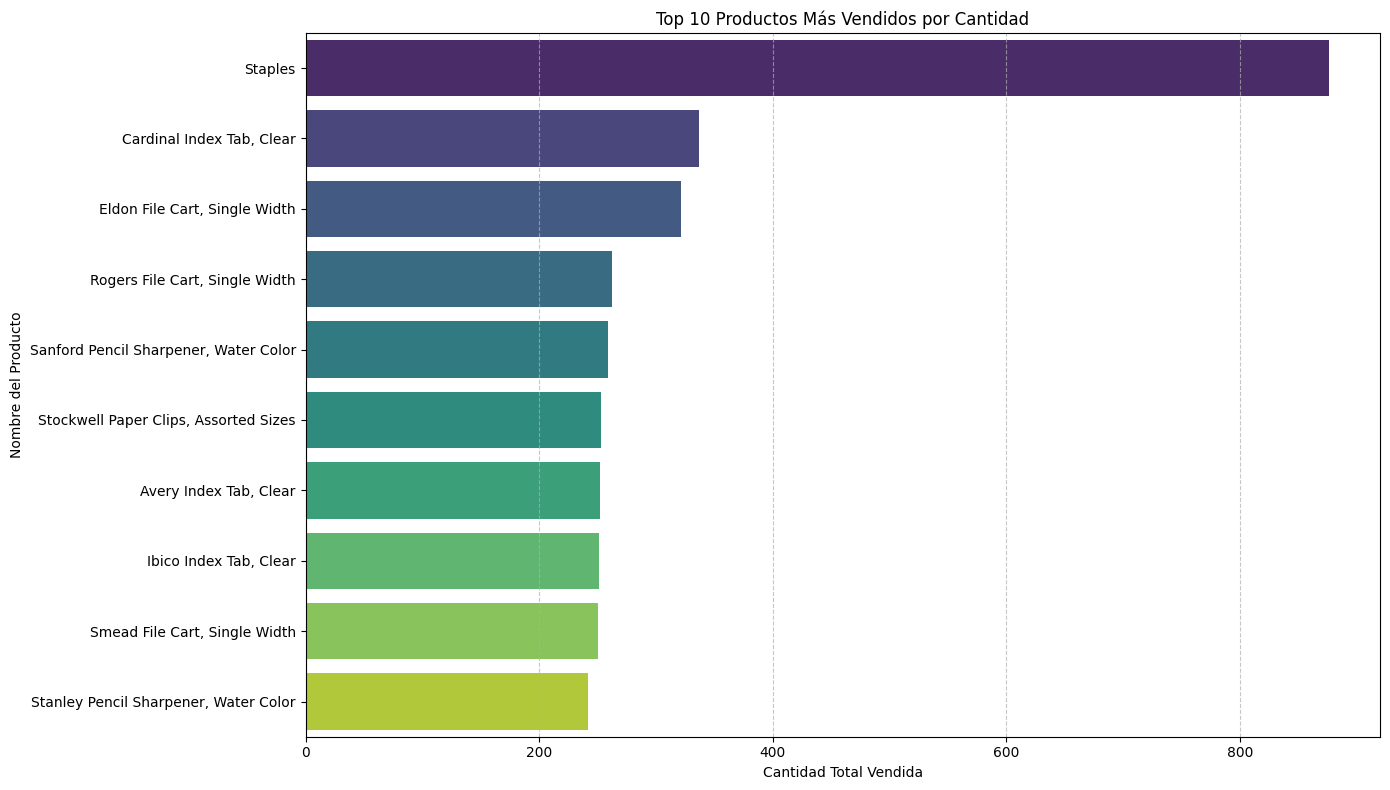

In [30]:
plt.figure(figsize=(14, 8))
sns.barplot(x='total_quantity_sold', y='product_name', data=top_10_products, palette='viridis', hue='product_name', legend=False)
plt.title('Top 10 Productos Más Vendidos por Cantidad')
plt.xlabel('Cantidad Total Vendida')
plt.ylabel('Nombre del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Influencia de Categorías de Producto por Mercado

Vamos a explorar qué categorías de productos tienen mayor impacto (en términos de ventas) dentro de cada mercado. Esto nos ayudará a entender las preferencias regionales.

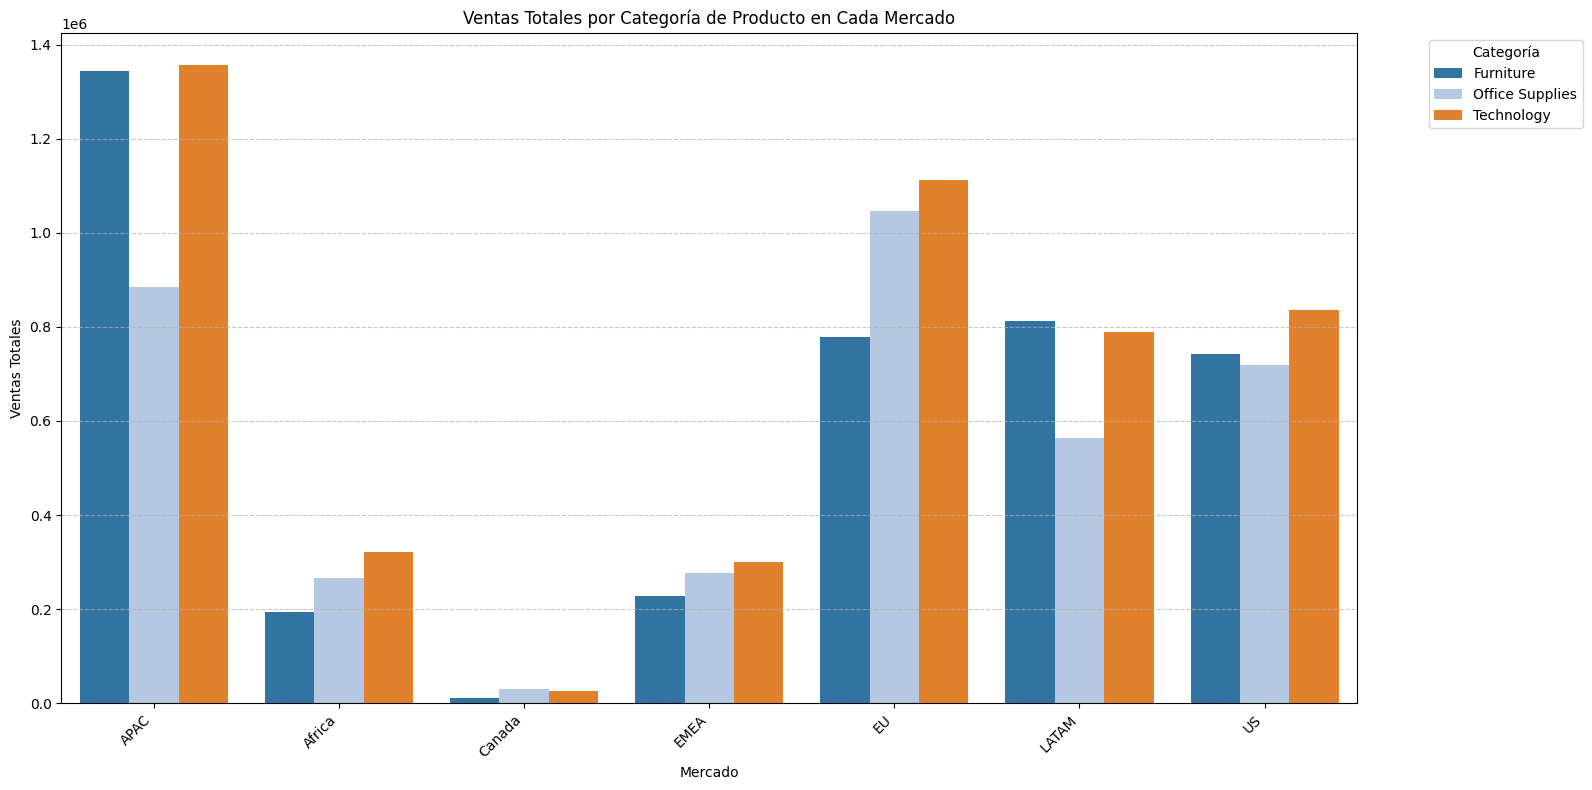

In [31]:
# Calcular las ventas totales por categoría y mercado
sales_by_market_category = df_borrador.groupby(['market', 'category'])['sales'].sum().reset_index()

# Crear un gráfico de barras apiladas para visualizar la distribución de ventas por categoría en cada mercado
plt.figure(figsize=(16, 8))
sns.barplot(x='market', y='sales', hue='category', data=sales_by_market_category, palette='tab20')
plt.title('Ventas Totales por Categoría de Producto en Cada Mercado')
plt.xlabel('Mercado')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ventas Totales por Categoría de Producto por Segmento de Cliente

Este gráfico muestra cómo se distribuyen las ventas de las diferentes categorías de productos dentro de cada segmento de cliente, permitiéndonos identificar las preferencias de compra de cada grupo.

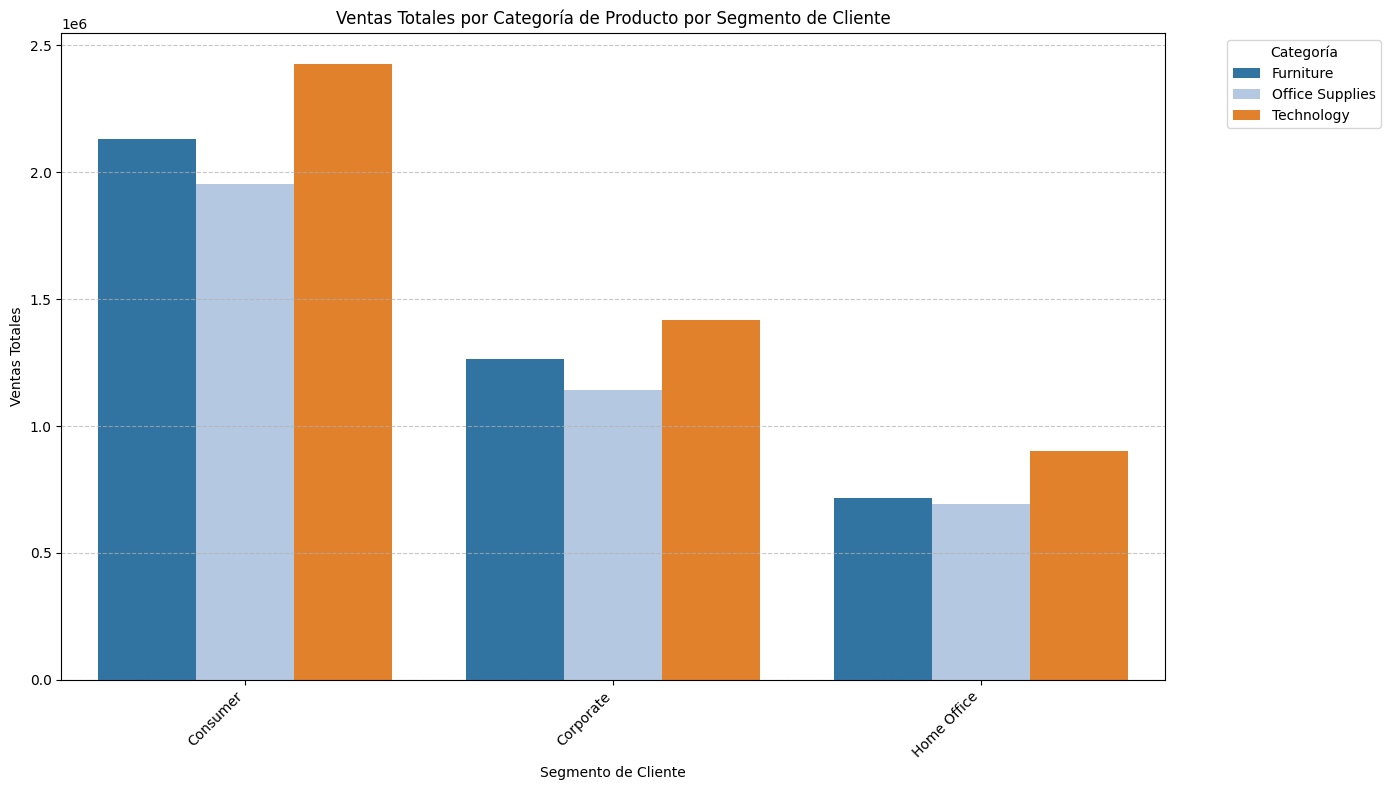

In [32]:
# Agrupar por segmento y categoría, y sumar las ventas
sales_by_segment_category = df_borrador.groupby(['segment', 'category'])['sales'].sum().reset_index()

# Crear el gráfico de barras apiladas
plt.figure(figsize=(14, 8))
sns.barplot(x='segment', y='sales', hue='category', data=sales_by_segment_category, palette='tab20')
plt.title('Ventas Totales por Categoría de Producto por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ventas por Segmento de Cliente

Ahora, analizaremos cómo se distribuyen las ventas entre los diferentes segmentos de clientes para identificar cuáles son los más lucrativos.

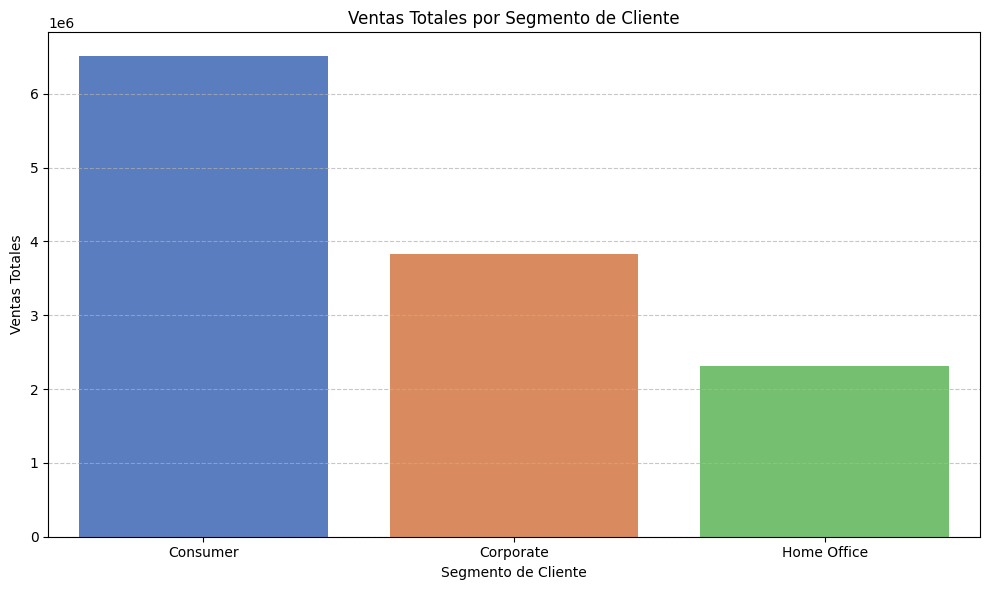

In [33]:
# Calcular las ventas totales por segmento de cliente
sales_by_segment = df_borrador.groupby('segment')['sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='segment', y='sales', data=sales_by_segment, palette='muted', hue='segment', legend=False)
plt.title('Ventas Totales por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Ventas Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Costo de Envío por Modo de Envío

Vamos a visualizar la distribución del `shipping_cost` para cada `ship_mode` utilizando un boxplot.

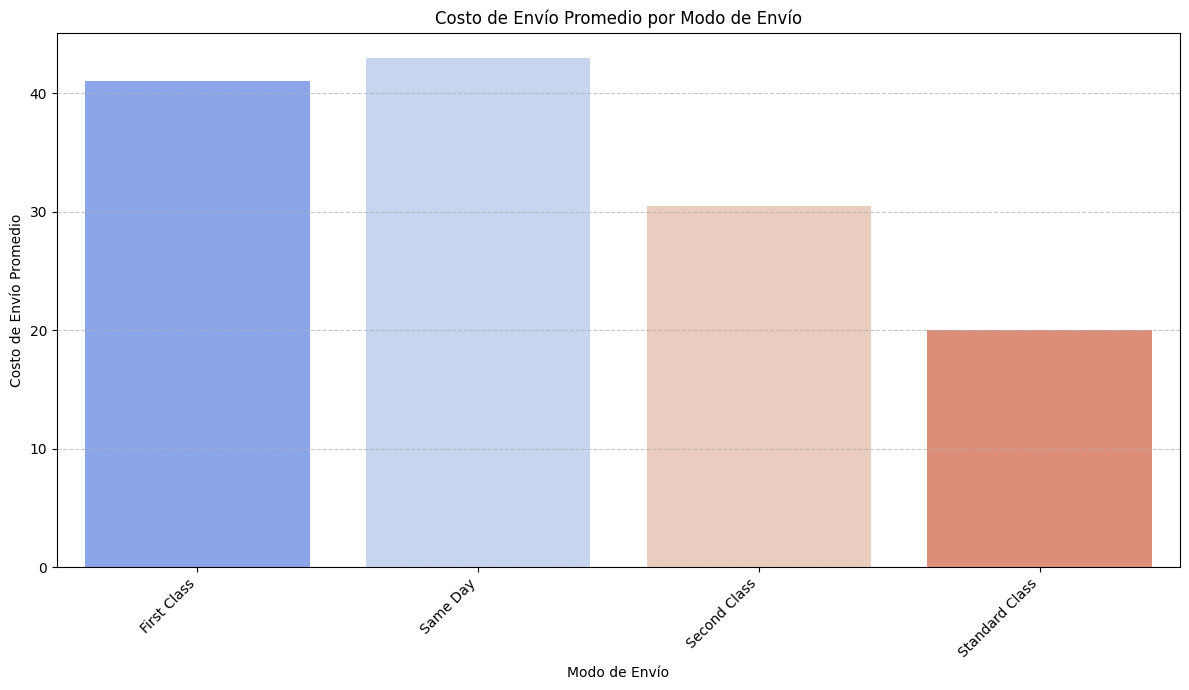

In [34]:
plt.figure(figsize=(12, 7))
mean_shipping_cost_by_mode = df_borrador.groupby('ship_mode')['shipping_cost'].mean().reset_index()
sns.barplot(x='ship_mode', y='shipping_cost', data=mean_shipping_cost_by_mode, palette='coolwarm', hue='ship_mode', legend=False)
plt.title('Costo de Envío Promedio por Modo de Envío')
plt.xlabel('Modo de Envío')
plt.ylabel('Costo de Envío Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Proporción de Modos de Envío por Segmento de Cliente

Vamos a explorar las preferencias de `ship_mode` dentro de cada `segment` de cliente.

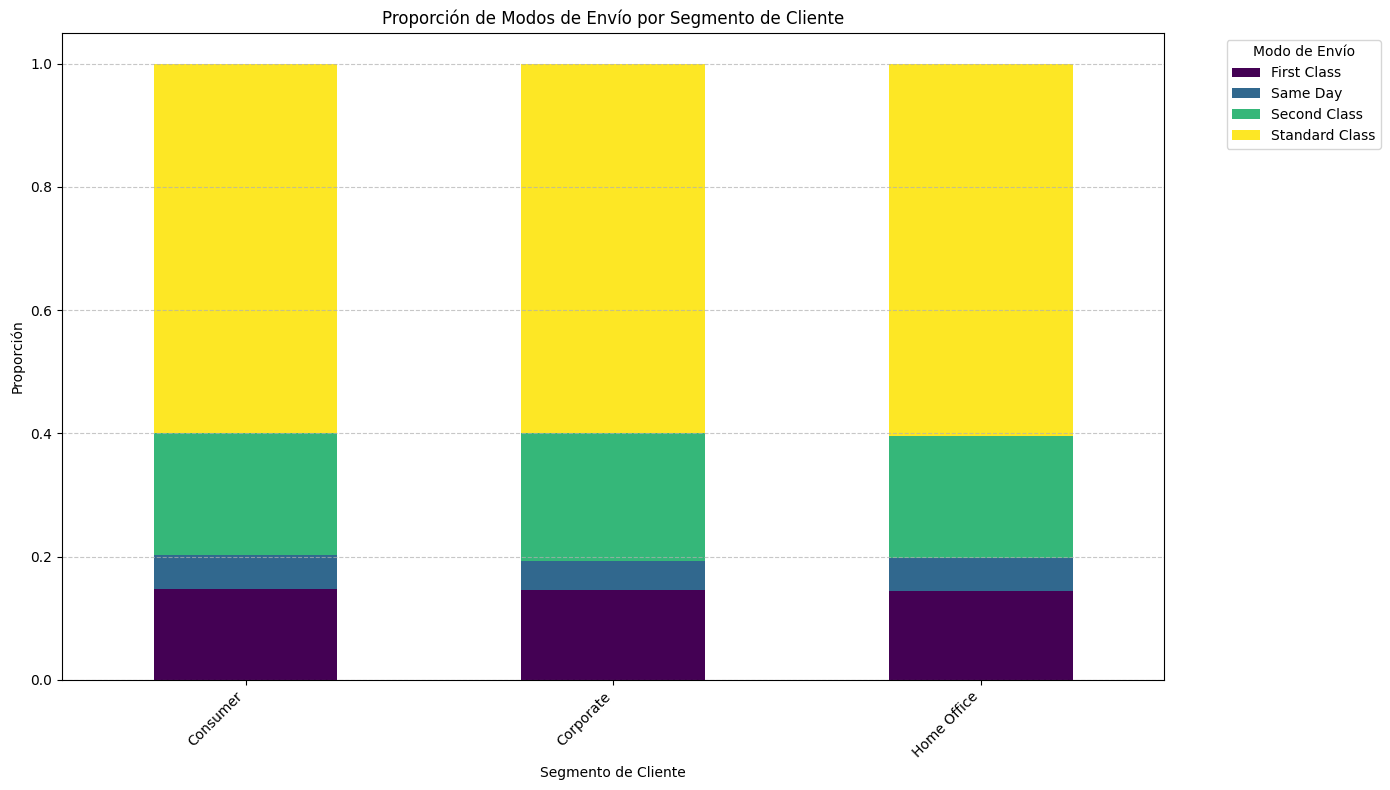

In [35]:
# Calcular la proporción de cada ship_mode por segmento de cliente directamente usando crosstab
ship_mode_segment_proportions = pd.crosstab(df_borrador['segment'], df_borrador['ship_mode'], normalize='index')

# Plotear el gráfico de barras apiladas
ship_mode_segment_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proporción de Modos de Envío por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modo de Envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Proporción de Modos de Envío por Mercado

Para entender las preferencias de `ship_mode` en cada `market`, crearemos un gráfico de barras apiladas.

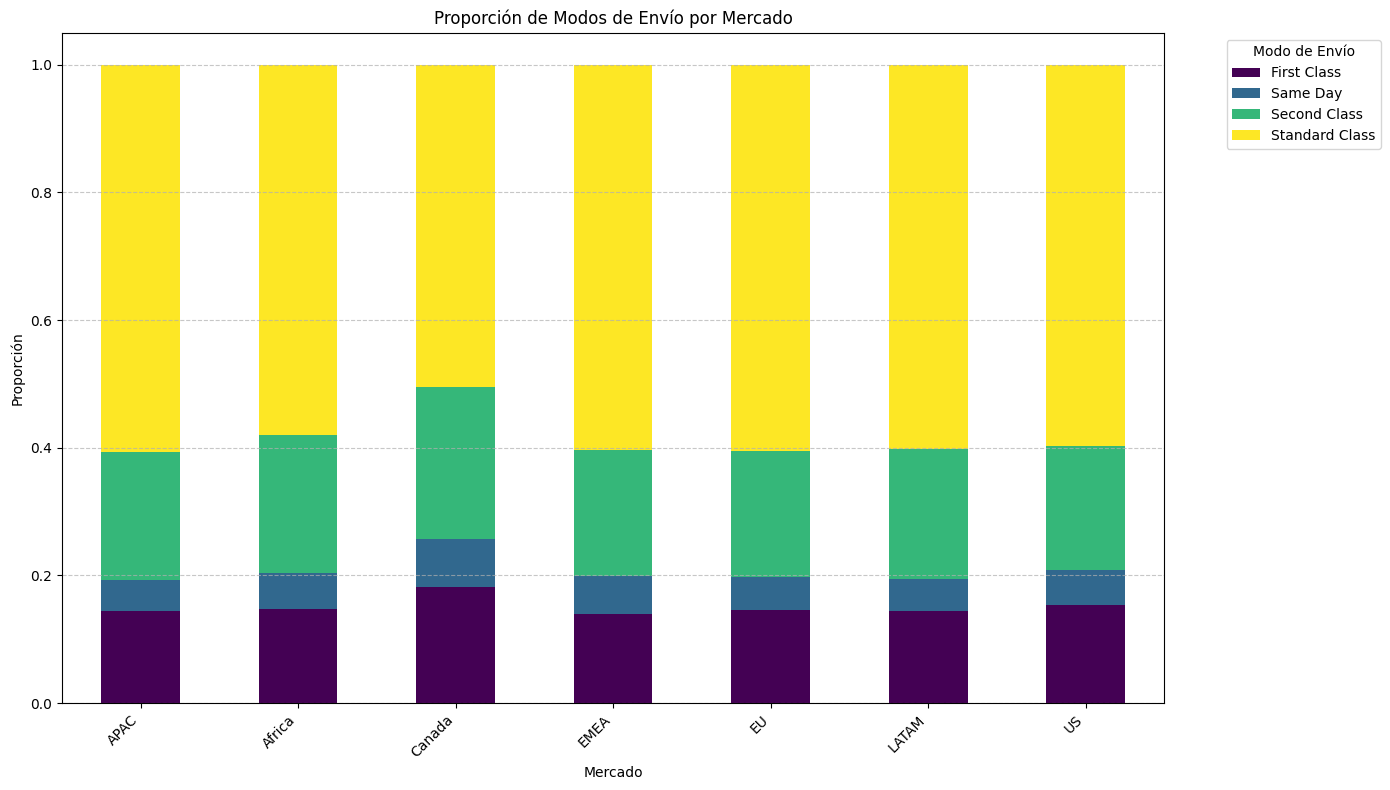

In [36]:
# Calcular la frecuencia de cada ship_mode por market
ship_mode_market_counts = df_borrador.groupby(['market', 'ship_mode']).size().unstack(fill_value=0)

# Convertir a proporciones para el gráfico apilado
ship_mode_market_proportions = ship_mode_market_counts.apply(lambda x: x / x.sum(), axis=1)

# Plotear el gráfico de barras apiladas
ship_mode_market_proportions.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proporción de Modos de Envío por Mercado')
plt.xlabel('Mercado')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modo de Envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

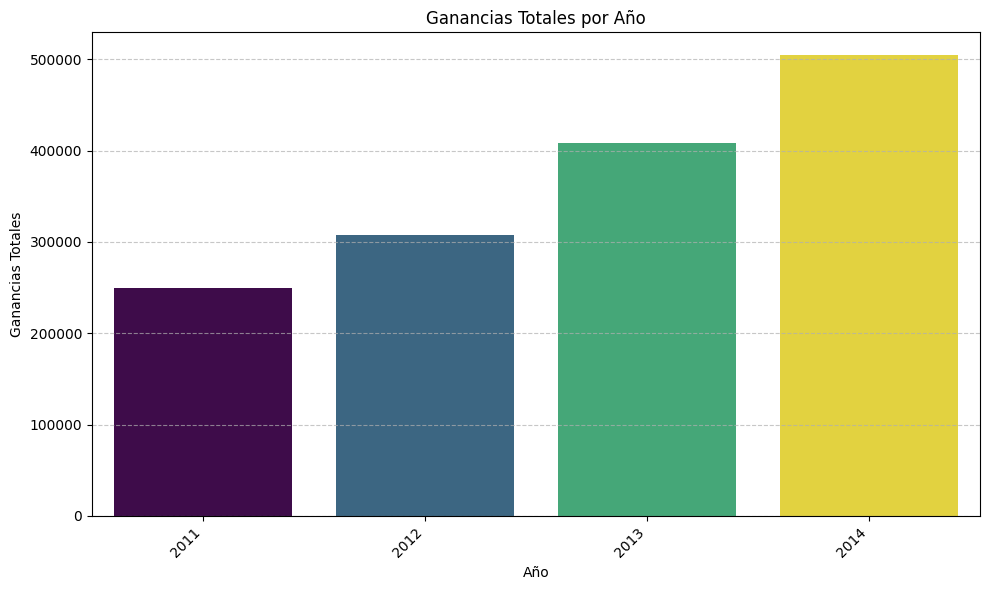

In [37]:
sales_by_year = df_borrador.groupby('year')['profit'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='profit', data=sales_by_year, palette='viridis', hue='year', legend=False)
plt.title('Ganancias Totales por Año')
plt.xlabel('Año')
plt.ylabel('Ganancias Totales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# OUTLIERS

### Análisis de Outliers en `margen_unitario`

Vamos a identificar y cuantificar los outliers en la columna `margen_unitario` utilizando el método del rango intercuartílico (IQR).

In [80]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1 = df_borrador['margen_unitario'].quantile(0.25)
Q3 = df_borrador['margen_unitario'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Definir los límites para identificar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar los outliers
outliers = df_borrador[(df_borrador['margen_unitario'] < lower_bound) | (df_borrador['margen_unitario'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'margen_unitario': {len(outliers)}")
print(f"Porcentaje de outliers: {(len(outliers) / len(df_borrador) * 100):.2f}%")

if not outliers.empty:
    print("\nPrimeras 10 filas de outliers por margen unitario:")
    display(outliers.head(10))
else:
    print("No se encontraron outliers en la columna 'margen_unitario'.")

Q1 (25th percentile): 4.49
Q3 (75th percentile): 30.20
IQR: 25.71
Lower Bound for Outliers: -34.07
Upper Bound for Outliers: 68.76

Número total de filas: 51290
Número de outliers en 'margen_unitario': 5620
Porcentaje de outliers: 10.96%

Primeras 10 filas de outliers por margen unitario:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.00,106.1400,35.46,Medium,2011,204.000000,133.200000,70.800000
7,IN-2011-79397,2011-01-03,2011-01-03,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,OFF-AP-10000304,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.10,110.4120,125.32,Critical,2011,306.666667,40.268000,266.398667
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.40,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
9,IZ-2011-4680,2011-01-03,2011-01-07,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,FUR-NOV-10002791,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.00,253.3200,81.26,High,2011,166.750000,83.105000,83.645000
11,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,FUR-TA-10002797,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211,1,0.55,-70.3995,21.32,High,2011,468.888889,260.079500,208.809389
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.00,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",3029,8,0.00,999.3600,191.20,Medium,2011,378.625000,229.805000,148.820000
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2574,9,0.00,746.4078,258.99,High,2011,286.000000,174.289133,111.710867
59,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,610,2,0.00,274.4910,88.07,High,2011,305.000000,123.719500,181.280500
60,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,TEC-PH-10004977,Technology,Phones,GE 30524EE4,392,2,0.00,113.6742,62.37,High,2011,196.000000,107.977900,88.022100



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 5620


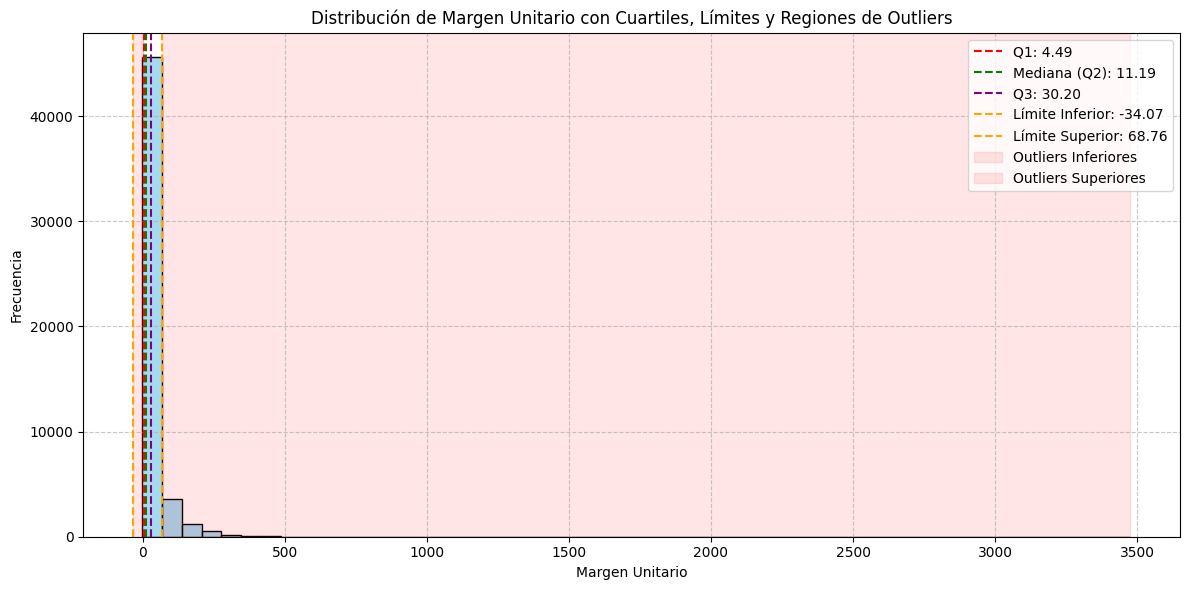

In [81]:
# --- Distribución y Outliers de 'margen_unitario' ---
Q2_margen_unitario = df_borrador['margen_unitario'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower = df_borrador[df_borrador['margen_unitario'] < lower_bound]
outliers_above_upper = df_borrador[df_borrador['margen_unitario'] > upper_bound]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['margen_unitario'], bins=50, kde=False, color='skyblue')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1, color='red', linestyle='--', label=f'Q1: {Q1:.2f}')
plt.axvline(Q2_margen_unitario, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_margen_unitario:.2f}')
plt.axvline(Q3, color='purple', linestyle='--', label=f'Q3: {Q3:.2f}')
plt.axvline(lower_bound, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound:.2f}')
plt.axvline(upper_bound, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound:.2f}')

# Resaltar las áreas de outliers
plt.axvspan(df_borrador['margen_unitario'].min(), lower_bound, color='red', alpha=0.1, label='Outliers Inferiores')
plt.axvspan(upper_bound, df_borrador['margen_unitario'].max(), color='red', alpha=0.1, label='Outliers Superiores')

plt.title('Distribución de Margen Unitario con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Margen Unitario')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `sales`

Vamos a identificar y cuantificar los outliers en la columna `sales` utilizando el método del rango intercuartílico (IQR)

In [74]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_sales = df_borrador['sales'].quantile(0.25)
Q3_sales = df_borrador['sales'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_sales = Q3_sales - Q1_sales

# Definir los límites para identificar outliers
lower_bound_sales = Q1_sales - 1.5 * IQR_sales
upper_bound_sales = Q3_sales + 1.5 * IQR_sales

# Identificar los outliers
outliers_sales = df_borrador[(df_borrador['sales'] < lower_bound_sales) | (df_borrador['sales'] > upper_bound_sales)]

print(f"Q1 (25th percentile) para 'sales': {Q1_sales:.2f}")
print(f"Q3 (75th percentile) para 'sales': {Q3_sales:.2f}")
print(f"IQR para 'sales': {IQR_sales:.2f}")
print(f"Lower Bound para Outliers en 'sales': {lower_bound_sales:.2f}")
print(f"Upper Bound para Outliers en 'sales': {upper_bound_sales:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'sales': {len(outliers_sales)}")
print(f"Porcentaje de outliers en 'sales': {(len(outliers_sales) / len(df_borrador) * 100):.2f}%")

if not outliers_sales.empty:
    print("\nPrimeras 10 filas de outliers por sales:")
    display(outliers_sales.head(10))
else:
    print("No se encontraron outliers en la columna 'sales'.")

Q1 (25th percentile) para 'sales': 31.00
Q3 (75th percentile) para 'sales': 251.00
IQR para 'sales': 220.00
Lower Bound para Outliers en 'sales': -299.00
Upper Bound para Outliers en 'sales': 581.00

Número total de filas: 51290
Número de outliers en 'sales': 5655
Porcentaje de outliers en 'sales': 11.03%

Primeras 10 filas de outliers por sales:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
9,IZ-2011-4680,2011-01-03,2011-01-07,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,FUR-NOV-10002791,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.3200,81.26,High,2011,166.750000,83.105000,83.645000
12,ES-2011-4869686,2011-01-03,2011-01-07,Standard Class,Dorothy Dickinson,Consumer,England,United Kingdom,EU,North,FUR-BO-10000728,Furniture,Bookcases,"Dania Corner Shelving, Traditional",854,7,0.0,290.4300,12.56,Medium,2011,122.000000,78.715714,43.284286
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.0,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",3029,8,0.0,999.3600,191.20,Medium,2011,378.625000,229.805000,148.820000
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2574,9,0.0,746.4078,258.99,High,2011,286.000000,174.289133,111.710867
59,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,610,2,0.0,274.4910,88.07,High,2011,305.000000,123.719500,181.280500
64,ES-2011-5433855,2011-01-07,2011-01-08,First Class,Dave Poirier,Corporate,Provence-Alpes-Côte d'Azur,France,EU,Central,OFF-ST-10004855,Office Supplies,Storage,"Smead Lockers, Industrial",716,4,0.1,143.1600,32.46,Medium,2011,198.888889,135.095000,63.793889
67,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,TEC-PH-10004539,Technology,Phones,Wireless Extenders zBoost YX545 SOHO Signal Bo...,756,4,0.0,204.1092,13.82,High,2011,189.000000,134.517700,54.482300
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",2479,6,0.0,49.5000,349.87,High,2011,413.166667,346.605000,66.561667



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 5655


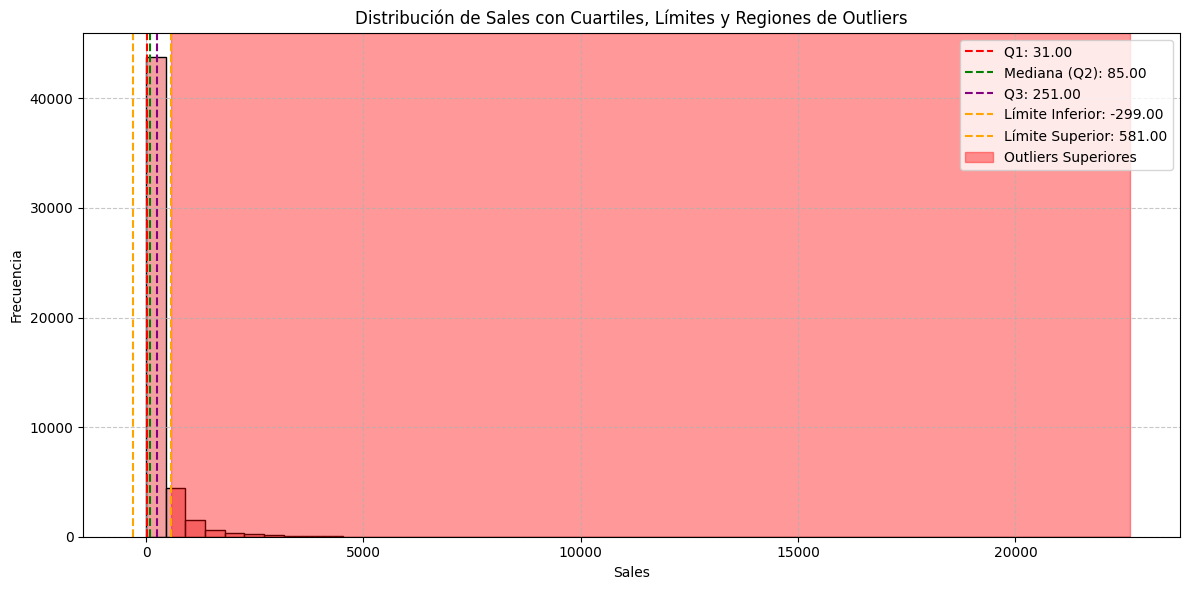

In [76]:
# --- Distribución y Outliers de 'sales' ---
Q2_sales = df_borrador['sales'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower_sales = df_borrador[df_borrador['sales'] < lower_bound_sales]
outliers_above_upper_sales = df_borrador[df_borrador['sales'] > upper_bound_sales]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower_sales)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper_sales)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['sales'], bins=50, kde=False, color='lightcoral')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_sales, color='red', linestyle='--', label=f'Q1: {Q1_sales:.2f}')
plt.axvline(Q2_sales, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_sales:.2f}')
plt.axvline(Q3_sales, color='purple', linestyle='--', label=f'Q3: {Q3_sales:.2f}')
plt.axvline(lower_bound_sales, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_sales:.2f}')
plt.axvline(upper_bound_sales, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_sales:.2f}')

# Resaltar las áreas de outliers
min_sales_val = df_borrador['sales'].min()
max_sales_val = df_borrador['sales'].max()

# Dado que lower_bound_sales is negative and sales are non-negative, only highlight upper outliers
plt.axvspan(upper_bound_sales, max_sales_val, color='red', alpha=0.4, label='Outliers Superiores')

plt.title('Distribución de Sales con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Sales')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `profit`

Vamos a identificar y cuantificar los outliers en la columna `profit` utilizando el método del rango intercuartílico (IQR).

In [83]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil) para 'profit'
Q1_profit = df_borrador['profit'].quantile(0.25)
Q3_profit = df_borrador['profit'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR) para 'profit'
IQR_profit = Q3_profit - Q1_profit

# Definir los límites para identificar outliers en 'profit'
lower_bound_profit = Q1_profit - 1.5 * IQR_profit
upper_bound_profit = Q3_profit + 1.5 * IQR_profit

# Identificar los outliers en 'profit'
outliers_profit = df_borrador[(df_borrador['profit'] < lower_bound_profit) | (df_borrador['profit'] > upper_bound_profit)]

print(f"Q1 (25th percentile) para 'profit': {Q1_profit:.2f}")
print(f"Q3 (75th percentile) para 'profit': {Q3_profit:.2f}")
print(f"IQR para 'profit': {IQR_profit:.2f}")
print(f"Lower Bound para Outliers en 'profit': {lower_bound_profit:.2f}")
print(f"Upper Bound para Outliers en 'profit': {upper_bound_profit:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'profit': {len(outliers_profit)}")
print(f"Porcentaje de outliers en 'profit': {(len(outliers_profit) / len(df_borrador) * 100):.2f}%")

if not outliers_profit.empty:
    print("\nPrimeras 10 filas de outliers por profit:")
    display(outliers_profit.head(10))
else:
    print("No se encontraron outliers en la columna 'profit'.")

Q1 (25th percentile) para 'profit': 0.00
Q3 (75th percentile) para 'profit': 36.81
IQR para 'profit': 36.81
Lower Bound para Outliers en 'profit': -55.22
Upper Bound para Outliers en 'profit': 92.03

Número total de filas: 51290
Número de outliers en 'profit': 9755
Porcentaje de outliers en 'profit': 19.02%

Primeras 10 filas de outliers por profit:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.00,106.1400,35.46,Medium,2011,204.000000,133.200000,70.800000
7,IN-2011-79397,2011-01-03,2011-01-03,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,OFF-AP-10000304,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.10,110.4120,125.32,Critical,2011,306.666667,40.268000,266.398667
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.40,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
9,IZ-2011-4680,2011-01-03,2011-01-07,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,FUR-NOV-10002791,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.00,253.3200,81.26,High,2011,166.750000,83.105000,83.645000
10,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,OFF-ST-10003020,Office Supplies,Storage,"Tenex Lockers, Industrial",338,3,0.45,-122.8005,33.75,High,2011,204.848485,142.350167,62.498318
11,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,FUR-TA-10002797,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211,1,0.55,-70.3995,21.32,High,2011,468.888889,260.079500,208.809389
12,ES-2011-4869686,2011-01-03,2011-01-07,Standard Class,Dorothy Dickinson,Consumer,England,United Kingdom,EU,North,FUR-BO-10000728,Furniture,Bookcases,"Dania Corner Shelving, Traditional",854,7,0.00,290.4300,12.56,Medium,2011,122.000000,78.715714,43.284286
14,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,FUR-CH-10000214,Furniture,Chairs,"Hon Rocking Chair, Set of Two",159,2,0.40,-95.6760,10.07,Low,2011,132.500000,122.303000,10.197000
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.00,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
33,US-2011-136007,2011-01-04,2011-01-11,Standard Class,Beth Thompson,Home Office,Alagoas,Brazil,LATAM,South,OFF-EN-10004956,Office Supplies,Envelopes,"Jiffy Interoffice Envelope, Set of 50",74,6,0.60,-107.8560,7.04,Medium,2011,30.833333,29.136000,1.697333



Número de outliers por debajo del Límite Inferior: 3525
Número de outliers por encima del Límite Superior: 6230


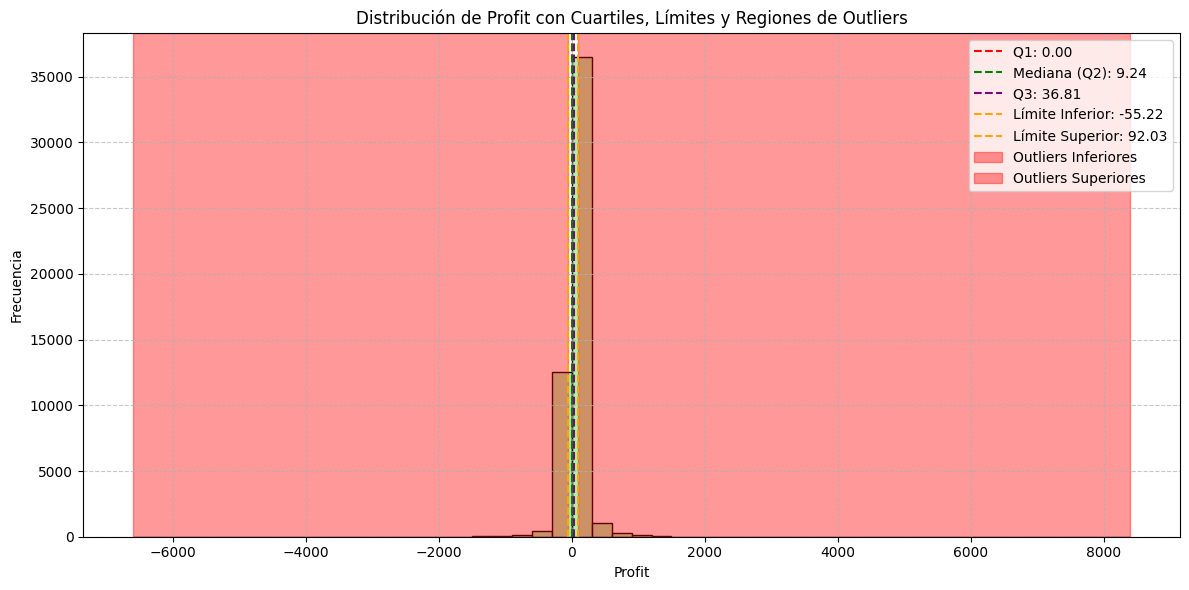

In [84]:
# --- Distribución y Outliers de 'profit' ---
Q2_profit = df_borrador['profit'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower_profit = df_borrador[df_borrador['profit'] < lower_bound_profit]
outliers_above_upper_profit = df_borrador[df_borrador['profit'] > upper_bound_profit]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower_profit)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper_profit)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['profit'], bins=50, kde=False, color='lightgreen')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_profit, color='red', linestyle='--', label=f'Q1: {Q1_profit:.2f}')
plt.axvline(Q2_profit, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_profit:.2f}')
plt.axvline(Q3_profit, color='purple', linestyle='--', label=f'Q3: {Q3_profit:.2f}')
plt.axvline(lower_bound_profit, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_profit:.2f}')
plt.axvline(upper_bound_profit, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_profit:.2f}')

# Resaltar las áreas de outliers
plt.axvspan(df_borrador['profit'].min(), lower_bound_profit, color='red', alpha=0.4, label='Outliers Inferiores')
plt.axvspan(upper_bound_profit, df_borrador['profit'].max(), color='red', alpha=0.4, label='Outliers Superiores')

plt.title('Distribución de Profit con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Profit')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `quantity`

Vamos a identificar y cuantificar los outliers en la columna `quantity` utilizando el método del rango intercuartílico (IQR).

In [100]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_quantity = df_borrador['quantity'].quantile(0.25)
Q3_quantity = df_borrador['quantity'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_quantity = Q3_quantity - Q1_quantity

# Definir los límites para identificar outliers
lower_bound_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_bound_quantity = Q3_quantity + 1.5 * IQR_quantity

# Identificar los outliers
outliers_quantity = df_borrador[(df_borrador['quantity'] < lower_bound_quantity) | (df_borrador['quantity'] > upper_bound_quantity)]

print(f"Q1 (25th percentile) para 'quantity': {Q1_quantity:.2f}")
print(f"Q3 (75th percentile) para 'quantity': {Q3_quantity:.2f}")
print(f"IQR para 'quantity': {IQR_quantity:.2f}")
print(f"Lower Bound para Outliers en 'quantity': {lower_bound_quantity:.2f}")
print(f"Upper Bound para Outliers en 'quantity': {upper_bound_quantity:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'quantity': {len(outliers_quantity)}")
print(f"Porcentaje de outliers en 'quantity': {(len(outliers_quantity) / len(df_borrador) * 100):.2f}%")

if not outliers_quantity.empty:
    print("\nPrimeras 10 filas de outliers por quantity:")
    display(outliers_quantity.head(10))
else:
    print("No se encontraron outliers en la columna 'quantity'.")

Q1 (25th percentile) para 'quantity': 2.00
Q3 (75th percentile) para 'quantity': 5.00
IQR para 'quantity': 3.00
Lower Bound para Outliers en 'quantity': -2.50
Upper Bound para Outliers en 'quantity': 9.50

Número total de filas: 51290
Número de outliers en 'quantity': 877
Porcentaje de outliers en 'quantity': 1.71%

Primeras 10 filas de outliers por quantity:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
126,US-2011-163874,2011-01-11,2011-01-12,First Class,Philip Fox,Consumer,México,Mexico,LATAM,North,OFF-ST-10003741,Office Supplies,Storage,"Smead Lockers, Blue",1323,10,0.000,238.00000,103.84,Medium,2011,132.300000,98.116000,34.184000
180,ES-2011-1043483,2011-01-14,2011-01-19,Standard Class,Sharelle Roach,Home Office,Vienna,Austria,EU,Central,OFF-PA-10001650,Office Supplies,Paper,"Xerox Message Books, Premium",224,11,0.000,102.96000,30.34,High,2011,20.363636,8.245455,12.118182
183,SF-2011-7680,2011-01-14,2011-01-21,Standard Class,Steve Nguyen,Home Office,Eastern Cape,South Africa,Africa,Africa,OFF-SAN-10001128,Office Supplies,Art,"Sanford Pens, Easy-Erase",136,12,0.000,31.32000,23.89,Low,2011,11.333333,6.732500,4.600833
185,MX-2011-135979,2011-01-14,2011-01-20,Standard Class,Bart Pistole,Corporate,Estelí,Nicaragua,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",246,12,0.000,7.20000,11.88,Medium,2011,20.500000,18.910000,1.590000
213,MX-2011-145765,2011-01-17,2011-01-22,Standard Class,Alan Haines,Corporate,San Salvador,El Salvador,LATAM,Central,TEC-CO-10003142,Technology,Copiers,"Hewlett Fax and Copier, Laser",1412,11,0.002,251.71124,159.52,High,2011,128.620878,90.978978,37.641900
214,ES-2011-3305419,2011-01-17,2011-01-19,Second Class,Edward Hooks,Corporate,Ile-de-France,France,EU,Central,OFF-AR-10001230,Office Supplies,Art,"Binney & Smith Markers, Water Color",300,11,0.000,50.82000,38.70,High,2011,27.272727,19.134545,8.138182
230,ZA-2011-9910,2011-01-19,2011-01-21,First Class,Patrick Gardner,Consumer,Eastern,Zambia,Africa,Africa,OFF-BIN-10000772,Office Supplies,Art,"Binney & Smith Pencil Sharpener, Water Color",418,14,0.000,95.76000,143.67,Critical,2011,29.857143,12.755000,17.102143
252,CA-2011-146591,2011-01-20,2011-01-21,First Class,Toby Swindell,Consumer,Arizona,United States,US,West,OFF-BI-10003676,Office Supplies,Binders,"GBC Standard Recycled Report Covers, Clear Pla...",32,10,0.700,-23.71600,6.03,Medium,2011,10.666667,4.968600,5.698067
313,IN-2011-85459,2011-01-24,2011-01-30,Standard Class,Jill Matthias,Consumer,Wellington,New Zealand,APAC,Oceania,OFF-EN-10003770,Office Supplies,Envelopes,"Kraft Manila Envelope, with clear poly window",420,14,0.000,147.00000,20.03,Medium,2011,30.000000,18.069286,11.930714
333,ES-2011-3746760,2011-01-25,2011-02-01,Standard Class,Filia McAdams,Corporate,North Rhine-Westphalia,Germany,EU,Central,OFF-BI-10001192,Office Supplies,Binders,"Cardinal Binder, Clear",133,10,0.000,3.90000,8.94,Medium,2011,13.300000,12.016000,1.284000



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 877


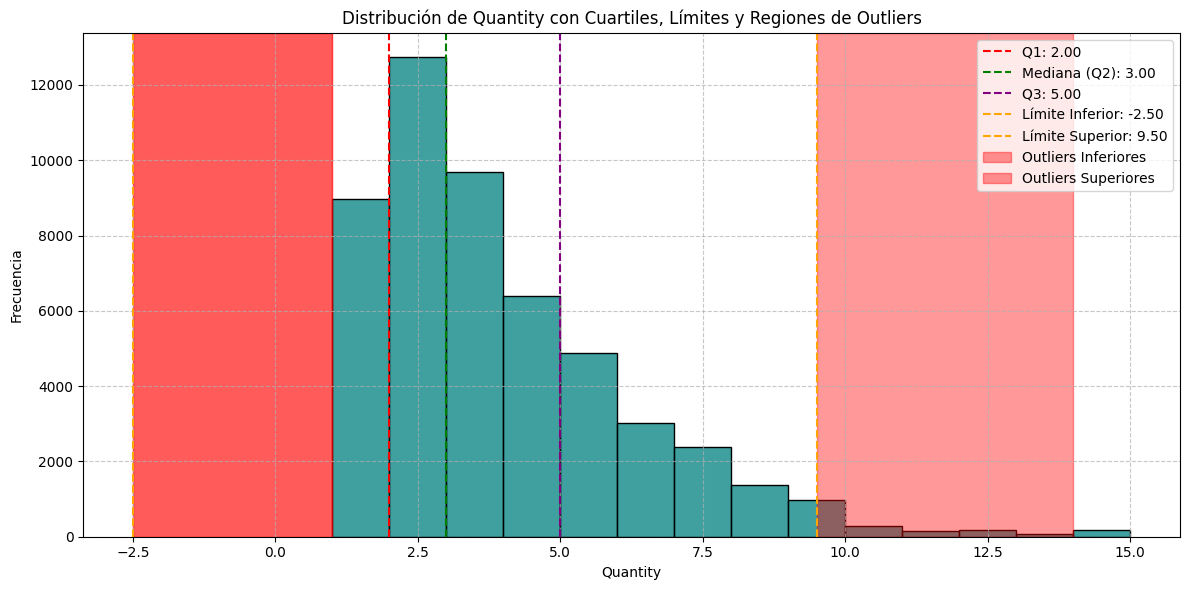

In [66]:
# --- Distribución y Outliers de 'quantity' ---
Q2_quantity = df_borrador['quantity'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower_quantity = df_borrador[df_borrador['quantity'] < lower_bound_quantity]
outliers_above_upper_quantity = df_borrador[df_borrador['quantity'] > upper_bound_quantity]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower_quantity)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper_quantity)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['quantity'], bins=range(int(df_borrador['quantity'].min()), int(df_borrador['quantity'].max()) + 2), kde=False, color='teal')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_quantity, color='red', linestyle='--', label=f'Q1: {Q1_quantity:.2f}')
plt.axvline(Q2_quantity, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_quantity:.2f}')
plt.axvline(Q3_quantity, color='purple', linestyle='--', label=f'Q3: {Q3_quantity:.2f}')
plt.axvline(lower_bound_quantity, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_quantity:.2f}')
plt.axvline(upper_bound_quantity, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_quantity:.2f}')

# Resaltar las áreas de outliers
# Ajuste para el rango de bins para evitar que el sombreado se extienda indefinidamente si los límites son muy extremos
min_quantity_plot = df_borrador['quantity'].min()
max_quantity_plot = df_borrador['quantity'].max()

plt.axvspan(min_quantity_plot, min(lower_bound_quantity, max_quantity_plot), color='red', alpha=0.4, label='Outliers Inferiores')
plt.axvspan(max(lower_bound_quantity, min_quantity_plot), lower_bound_quantity, color='red', alpha=0.4)

plt.axvspan(upper_bound_quantity, max_quantity_plot, color='red', alpha=0.4, label='Outliers Superiores')

plt.title('Distribución de Quantity con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Quantity')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `shipping_cost`

Vamos a identificar y cuantificar los outliers en la columna `shipping_cost` utilizando el método del rango intercuartílico (IQR).

In [101]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_shipping_cost = df_borrador['shipping_cost'].quantile(0.25)
Q3_shipping_cost = df_borrador['shipping_cost'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_shipping_cost = Q3_shipping_cost - Q1_shipping_cost

# Definir los límites para identificar outliers
lower_bound_shipping_cost = Q1_shipping_cost - 1.5 * IQR_shipping_cost
upper_bound_shipping_cost = Q3_shipping_cost + 1.5 * IQR_shipping_cost

# Identificar los outliers
outliers_shipping_cost = df_borrador[(df_borrador['shipping_cost'] < lower_bound_shipping_cost) | (df_borrador['shipping_cost'] > upper_bound_shipping_cost)]

print(f"Q1 (25th percentile) para 'shipping_cost': {Q1_shipping_cost:.2f}")
print(f"Q3 (75th percentile) para 'shipping_cost': {Q3_shipping_cost:.2f}")
print(f"IQR para 'shipping_cost': {IQR_shipping_cost:.2f}")
print(f"Lower Bound para Outliers en 'shipping_cost': {lower_bound_shipping_cost:.2f}")
print(f"Upper Bound para Outliers en 'shipping_cost': {upper_bound_shipping_cost:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'shipping_cost': {len(outliers_shipping_cost)}")
print(f"Porcentaje de outliers en 'shipping_cost': {(len(outliers_shipping_cost) / len(df_borrador) * 100):.2f}%")

if not outliers_shipping_cost.empty:
    print("\nPrimeras 10 filas de outliers por shipping_cost:")
    display(outliers_shipping_cost.head(10))
else:
    print("No se encontraron outliers en la columna 'shipping_cost'.")

# --- Distribución y Outliers de 'shipping_cost' ---
Q2_shipping_cost = df_borrador['shipping_cost'].median()

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['shipping_cost'], bins=50, kde=True, color='purple')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_shipping_cost, color='red', linestyle='--', label=f'Q1: {Q1_shipping_cost:.2f}')
plt.axvline(Q2_shipping_cost, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_shipping_cost:.2f}')
plt.axvline(Q3_shipping_cost, color='purple', linestyle='--', label=f'Q3: {Q3_shipping_cost:.2f}')
plt.axvline(lower_bound_shipping_cost, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_shipping_cost:.2f}')
plt.axvline(upper_bound_shipping_cost, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_shipping_cost:.2f}')

plt.title('Distribución de Shipping Cost con Cuartiles y Límites de Outliers')
plt.xlabel('Shipping Cost')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Q1 (25th percentile) para 'shipping_cost': 2.61
Q3 (75th percentile) para 'shipping_cost': 24.45
IQR para 'shipping_cost': 21.84
Lower Bound para Outliers en 'shipping_cost': -30.15
Upper Bound para Outliers en 'shipping_cost': 57.21

Número total de filas: 51290
Número de outliers en 'shipping_cost': 5909
Porcentaje de outliers en 'shipping_cost': 11.52%

Primeras 10 filas de outliers por shipping_cost:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
7,IN-2011-79397,2011-01-03,2011-01-03,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,OFF-AP-10000304,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.1,110.4120,125.32,Critical,2011,306.666667,40.268000,266.398667
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
9,IZ-2011-4680,2011-01-03,2011-01-07,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,FUR-NOV-10002791,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.3200,81.26,High,2011,166.750000,83.105000,83.645000
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.0,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",3029,8,0.0,999.3600,191.20,Medium,2011,378.625000,229.805000,148.820000
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2574,9,0.0,746.4078,258.99,High,2011,286.000000,174.289133,111.710867
59,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,610,2,0.0,274.4910,88.07,High,2011,305.000000,123.719500,181.280500
60,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,TEC-PH-10004977,Technology,Phones,GE 30524EE4,392,2,0.0,113.6742,62.37,High,2011,196.000000,107.977900,88.022100
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",2479,6,0.0,49.5000,349.87,High,2011,413.166667,346.605000,66.561667
84,IN-2011-19330,2011-01-08,2011-01-12,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,TEC-MA-10002468,Technology,Machines,"Panasonic Inkjet, White",2174,7,0.0,260.8200,275.52,Medium,2011,310.571429,233.951429,76.620000



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 5909


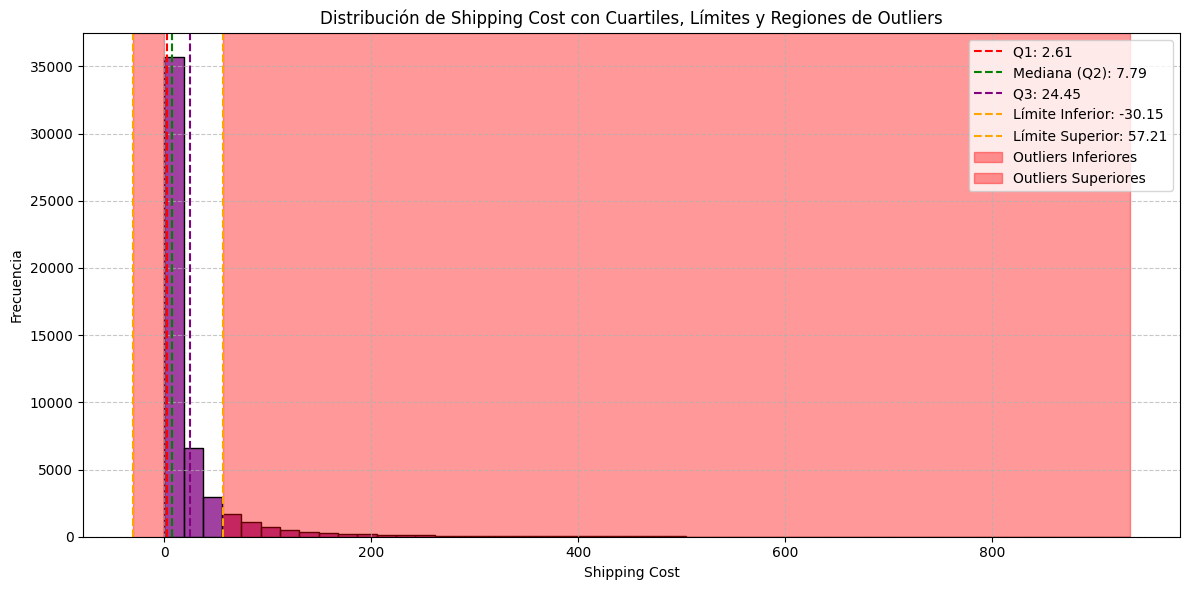

In [65]:
# --- Distribución y Outliers de 'shipping_cost' ---
Q2_shipping_cost = df_borrador['shipping_cost'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower_shipping_cost = df_borrador[df_borrador['shipping_cost'] < lower_bound_shipping_cost]
outliers_above_upper_shipping_cost = df_borrador[df_borrador['shipping_cost'] > upper_bound_shipping_cost]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower_shipping_cost)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper_shipping_cost)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['shipping_cost'], bins=50, kde=False, color='purple')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_shipping_cost, color='red', linestyle='--', label=f'Q1: {Q1_shipping_cost:.2f}')
plt.axvline(Q2_shipping_cost, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_shipping_cost:.2f}')
plt.axvline(Q3_shipping_cost, color='purple', linestyle='--', label=f'Q3: {Q3_shipping_cost:.2f}')
plt.axvline(lower_bound_shipping_cost, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_shipping_cost:.2f}')
plt.axvline(upper_bound_shipping_cost, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_shipping_cost:.2f}')

# Resaltar las áreas de outliers
plt.axvspan(df_borrador['shipping_cost'].min(), lower_bound_shipping_cost, color='red', alpha=0.4, label='Outliers Inferiores')
plt.axvspan(upper_bound_shipping_cost, df_borrador['shipping_cost'].max(), color='red', alpha=0.4, label='Outliers Superiores')

plt.title('Distribución de Shipping Cost con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Shipping Cost')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `discount`

Vamos a identificar y cuantificar los outliers en la columna `discount` utilizando el método del rango intercuartílico (IQR).

In [63]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_discount = df_borrador['discount'].quantile(0.25)
Q3_discount = df_borrador['discount'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_discount = Q3_discount - Q1_discount

# Definir los límites para identificar outliers
lower_bound_discount = Q1_discount - 1.5 * IQR_discount
upper_bound_discount = Q3_discount + 1.5 * IQR_discount

# Identificar los outliers
outliers_discount = df_borrador[(df_borrador['discount'] < lower_bound_discount) | (df_borrador['discount'] > upper_bound_discount)]

print(f"Q1 (25th percentile) para 'discount': {Q1_discount:.2f}")
print(f"Q3 (75th percentile) para 'discount': {Q3_discount:.2f}")
print(f"IQR para 'discount': {IQR_discount:.2f}")
print(f"Lower Bound para Outliers en 'discount': {lower_bound_discount:.2f}")
print(f"Upper Bound para Outliers en 'discount': {upper_bound_discount:.2f}")
print(f"Minimo valor: {df_borrador['discount'].min():.2f}")
print(f"Maximo valor: {df_borrador['discount'].max():.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'discount': {len(outliers_discount)}")
print(f"Porcentaje de outliers en 'discount': {(len(outliers_discount) / len(df_borrador) * 100):.2f}%")

if not outliers_discount.empty:
    print("\nPrimeras 10 filas de outliers por discount:")
    display(outliers_discount.head(10))
else:
    print("No se encontraron outliers en la columna 'discount'.")

Q1 (25th percentile) para 'discount': 0.00
Q3 (75th percentile) para 'discount': 0.20
IQR para 'discount': 0.20
Lower Bound para Outliers en 'discount': -0.30
Upper Bound para Outliers en 'discount': 0.50
Minimo valor: 0.00
Maximo valor: 0.85

Número total de filas: 51290
Número de outliers en 'discount': 4172
Porcentaje de outliers en 'discount': 8.13%

Primeras 10 filas de outliers por discount:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
11,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,FUR-TA-10002797,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211,1,0.55,-70.3995,21.32,High,2011,468.888889,260.079500,208.809389
33,US-2011-136007,2011-01-04,2011-01-11,Standard Class,Beth Thompson,Home Office,Alagoas,Brazil,LATAM,South,OFF-EN-10004956,Office Supplies,Envelopes,"Jiffy Interoffice Envelope, Set of 50",74,6,0.60,-107.8560,7.04,Medium,2011,30.833333,29.136000,1.697333
49,CA-2011-112326,2011-01-05,2011-01-09,Standard Class,Phillina Ober,Home Office,Illinois,United States,US,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,4,2,0.80,-5.4870,0.55,High,2011,10.000000,4.468500,5.531500
85,IT-2011-4546695,2011-01-08,2011-01-14,Standard Class,Darren Powers,Consumer,Midi-Pyrénées,France,EU,Central,FUR-BO-10003103,Furniture,Bookcases,"Ikea Classic Bookcase, Metal",987,6,0.60,-1011.6360,65.64,Medium,2011,411.250000,322.166000,89.084000
87,CA-2011-105417,2011-01-08,2011-01-13,Standard Class,Vivek Sundaresam,Consumer,Texas,United States,US,Central,FUR-FU-10004864,Furniture,Furnishings,"Howard Miller 14-1/2"" Diameter Chrome Round Wa...",77,3,0.60,-53.7096,6.69,Medium,2011,64.166667,41.339867,22.826800
90,NI-2011-4770,2011-01-08,2011-01-11,Second Class,Joe Elijah,Consumer,Lagos,Nigeria,Africa,Africa,OFF-AVE-10000608,Office Supplies,Binders,"Avery Index Tab, Economy",5,2,0.70,-4.5420,0.82,High,2011,8.333333,4.361000,3.972333
91,CA-2011-105417,2011-01-08,2011-01-13,Standard Class,Vivek Sundaresam,Consumer,Texas,United States,US,Central,OFF-BI-10003708,Office Supplies,Binders,Acco Four Pocket Poly Ring Binder with Label H...,10,7,0.80,-18.2525,0.63,Medium,2011,7.142857,3.946071,3.196786
132,ES-2011-4359424,2011-01-11,2011-01-15,Standard Class,Dorothy Dickinson,Consumer,Murcia,Spain,EU,South,FUR-TA-10001693,Furniture,Tables,"Bevis Training Table, with Bottom Storage",268,2,0.60,-341.7360,21.49,High,2011,335.000000,294.123000,40.877000
136,TU-2011-800,2011-01-11,2011-01-15,Standard Class,Chuck Sachs,Consumer,Bursa,Turkey,EMEA,EMEA,FUR-SAF-10003540,Furniture,Bookcases,"Safco Floating Shelf Set, Metal",157,2,0.60,-117.7200,12.45,High,2011,196.250000,131.135000,65.115000
156,NI-2011-1670,2011-01-12,2011-01-16,Standard Class,Shaun Chance,Corporate,Lagos,Nigeria,Africa,Africa,OFF-FEL-10001792,Office Supplies,Storage,"Fellowes Folders, Wire Frame",15,2,0.70,-22.4580,1.27,Medium,2011,25.000000,18.094000,6.906000



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 4172


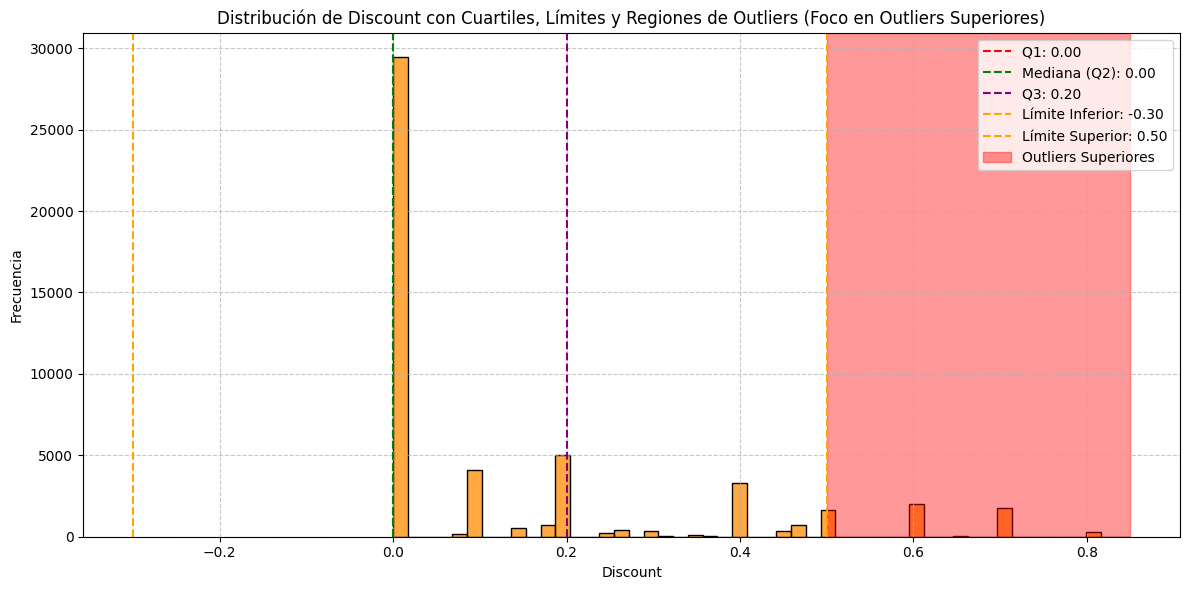

In [64]:
Q2_discount = df_borrador['discount'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower_discount = df_borrador[df_borrador['discount'] < lower_bound_discount]
outliers_above_upper_discount = df_borrador[df_borrador['discount'] > upper_bound_discount]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower_discount)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper_discount)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['discount'], bins=50, kde=False, color='darkorange')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_discount, color='red', linestyle='--', label=f'Q1: {Q1_discount:.2f}')
plt.axvline(Q2_discount, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_discount:.2f}')
plt.axvline(Q3_discount, color='purple', linestyle='--', label=f'Q3: {Q3_discount:.2f}')
plt.axvline(lower_bound_discount, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_discount:.2f}')
plt.axvline(upper_bound_discount, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_discount:.2f}')

# Resaltar las áreas de outliers - solo los outliers superiores son relevantes para 'discount'
# El límite inferior es negativo, y 'discount' no tiene valores negativos, por lo que no hay outliers inferiores.
plt.axvspan(upper_bound_discount, df_borrador['discount'].max(), color='red', alpha=0.4, label='Outliers Superiores') # alpha aumentada para mayor visibilidad

plt.title('Distribución de Discount con Cuartiles, Límites y Regiones de Outliers (Foco en Outliers Superiores)')
plt.xlabel('Discount')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `precio_unidad`

Ahora, vamos a identificar y cuantificar los outliers en la columna `precio_unidad` utilizando el método del rango intercuartílico (IQR).

In [49]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_precio_unidad = df_borrador['precio_unidad'].quantile(0.25)
Q3_precio_unidad = df_borrador['precio_unidad'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_precio_unidad = Q3_precio_unidad - Q1_precio_unidad

# Definir los límites para identificar outliers
lower_bound_precio_unidad = Q1_precio_unidad - 1.5 * IQR_precio_unidad
upper_bound_precio_unidad = Q3_precio_unidad + 1.5 * IQR_precio_unidad

# Identificar los outliers
outliers_precio_unidad = df_borrador[(df_borrador['precio_unidad'] < lower_bound_precio_unidad) | (df_borrador['precio_unidad'] > upper_bound_precio_unidad)]

print(f"Q1 (25th percentile) para 'precio_unidad': {Q1_precio_unidad:.2f}")
print(f"Q3 (75th percentile) para 'precio_unidad': {Q3_precio_unidad:.2f}")
print(f"IQR para 'precio_unidad': {IQR_precio_unidad:.2f}")
print(f"Lower Bound para Outliers en 'precio_unidad': {lower_bound_precio_unidad:.2f}")
print(f"Upper Bound para Outliers en 'precio_unidad': {upper_bound_precio_unidad:.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'precio_unidad': {len(outliers_precio_unidad)}")
print(f"Porcentaje de outliers en 'precio_unidad': {(len(outliers_precio_unidad) / len(df_borrador) * 100):.2f}%")

if not outliers_precio_unidad.empty:
    print("\nPrimeras 10 filas de outliers por precio_unidad:")
    display(outliers_precio_unidad.head(10))
else:
    print("No se encontraron outliers en la columna 'precio_unidad'.")

Q1 (25th percentile) para 'precio_unidad': 14.12
Q3 (75th percentile) para 'precio_unidad': 103.50
IQR para 'precio_unidad': 89.38
Lower Bound para Outliers en 'precio_unidad': -119.96
Upper Bound para Outliers en 'precio_unidad': 237.57

Número total de filas: 51290
Número de outliers en 'precio_unidad': 5032
Porcentaje de outliers en 'precio_unidad': 9.81%

Primeras 10 filas de outliers por precio_unidad:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
6,CA-2011-1510,2011-01-02,2011-01-06,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,TEC-OKI-10002750,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.00,3.1200,24.10,Medium,2011,314.000000,286.780000,27.220000
7,IN-2011-79397,2011-01-03,2011-01-03,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,OFF-AP-10000304,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.10,110.4120,125.32,Critical,2011,306.666667,40.268000,266.398667
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.40,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
11,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,FUR-TA-10002797,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211,1,0.55,-70.3995,21.32,High,2011,468.888889,260.079500,208.809389
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.00,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",3029,8,0.00,999.3600,191.20,Medium,2011,378.625000,229.805000,148.820000
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2574,9,0.00,746.4078,258.99,High,2011,286.000000,174.289133,111.710867
59,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,610,2,0.00,274.4910,88.07,High,2011,305.000000,123.719500,181.280500
63,ID-2011-58670,2011-01-07,2011-01-11,Standard Class,Maribeth Schnelling,Consumer,National Capital,Philippines,APAC,Southeast Asia,TEC-AC-10003413,Technology,Accessories,"Logitech Router, Programmable",274,2,0.45,-44.8380,42.19,High,2011,249.090909,138.324000,110.766909
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",2479,6,0.00,49.5000,349.87,High,2011,413.166667,346.605000,66.561667



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 5032


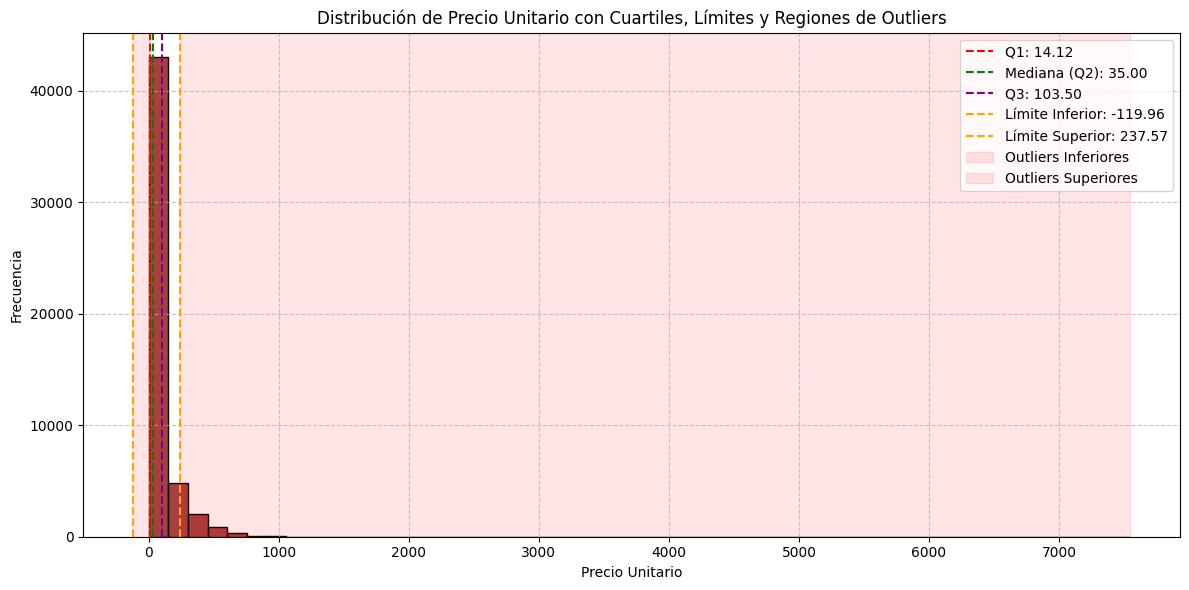

In [51]:
# --- Distribución y Outliers de 'precio_unidad' ---
Q2_precio_unidad = df_borrador['precio_unidad'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower_precio_unidad = df_borrador[df_borrador['precio_unidad'] < lower_bound_precio_unidad]
outliers_above_upper_precio_unidad = df_borrador[df_borrador['precio_unidad'] > upper_bound_precio_unidad]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower_precio_unidad)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper_precio_unidad)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['precio_unidad'], bins=50, kde=False, color='darkred')


# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_precio_unidad, color='red', linestyle='--', label=f'Q1: {Q1_precio_unidad:.2f}')
plt.axvline(Q2_precio_unidad, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_precio_unidad:.2f}')
plt.axvline(Q3_precio_unidad, color='purple', linestyle='--', label=f'Q3: {Q3_precio_unidad:.2f}')
plt.axvline(lower_bound_precio_unidad, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_precio_unidad:.2f}')
plt.axvline(upper_bound_precio_unidad, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_precio_unidad:.2f}')

# Resaltar las áreas de outliers
plt.axvspan(df_borrador['precio_unidad'].min(), lower_bound_precio_unidad, color='red', alpha=0.1, label='Outliers Inferiores')
plt.axvspan(upper_bound_precio_unidad, df_borrador['precio_unidad'].max(), color='red', alpha=0.1, label='Outliers Superiores')

plt.title('Distribución de Precio Unitario con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Precio Unitario')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Outliers en `costo_unitario`
Vamos a identificar y cuantificar los outliers en la columna `costo_unitario` utilizando el método del rango intercuartílico (IQR).


In [47]:
# Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
Q1_costo_unitario = df_borrador['costo_unitario'].quantile(0.25)
Q3_costo_unitario = df_borrador['costo_unitario'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR_costo_unitario = Q3_costo_unitario - Q1_costo_unitario

# Definir los límites para identificar outliers
lower_bound_costo_unitario = Q1_costo_unitario - 1.5 * IQR_costo_unitario
upper_bound_costo_unitario = Q3_costo_unitario + 1.5 * IQR_costo_unitario

# Identificar los outliers
outliers_costo_unitario = df_borrador[(df_borrador['costo_unitario'] < lower_bound_costo_unitario) | (df_borrador['costo_unitario'] > upper_bound_costo_unitario)]

print(f"Q1 (25th percentile) para 'costo_unitario': {Q1_costo_unitario:.2f}")
print(f"Q3 (75th percentile) para 'costo_unitario': {Q3_costo_unitario:.2f}")
print(f"IQR para 'costo_unitario': {IQR_costo_unitario:.2f}")
print(f"Lower Bound para Outliers en 'costo_unitario': {lower_bound_costo_unitario:.2f}")
print(f"Upper Bound para Outliers en 'costo_unitario': {upper_bound_costo_unitario:.2f}")
print(f"Minimo valor: {df_borrador['costo_unitario'].min():.2f}")
print(f"Maximo valor: {df_borrador['costo_unitario'].max():.2f}")

print(f"\nNúmero total de filas: {len(df_borrador)}")
print(f"Número de outliers en 'costo_unitario': {len(outliers_costo_unitario)}")
print(f"Porcentaje de outliers en 'costo_unitario': {(len(outliers_costo_unitario) / len(df_borrador) * 100):.2f}% ")

if not outliers_costo_unitario.empty:
    print("\nPrimeras 10 filas de outliers por costo_unitario:")
    display(outliers_costo_unitario.head(10))
else:
    print("No se encontraron outliers en la columna 'costo_unitario'.")

Q1 (25th percentile) para 'costo_unitario': 8.75
Q3 (75th percentile) para 'costo_unitario': 65.64
IQR para 'costo_unitario': 56.89
Lower Bound para Outliers en 'costo_unitario': -76.58
Upper Bound para Outliers en 'costo_unitario': 150.97
Minimo valor: 0.11
Maximo valor: 4070.80

Número total de filas: 51290
Número de outliers en 'costo_unitario': 4951
Porcentaje de outliers en 'costo_unitario': 9.65% 

Primeras 10 filas de outliers por costo_unitario:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
6,CA-2011-1510,2011-01-02,2011-01-06,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,TEC-OKI-10002750,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.00,3.1200,24.10,Medium,2011,314.000000,286.780000,27.220000
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,TEC-CO-10004182,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.40,-319.4640,107.10,Low,2011,380.000000,281.091000,98.909000
11,IN-2011-65159,2011-01-03,2011-01-07,Second Class,Larry Blacks,Consumer,National Capital,Philippines,APAC,Southeast Asia,FUR-TA-10002797,Furniture,Tables,"Chromcraft Round Table, Adjustable Height",211,1,0.55,-70.3995,21.32,High,2011,468.888889,260.079500,208.809389
27,MX-2011-111255,2011-01-04,2011-01-09,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,FUR-BO-10001498,Furniture,Bookcases,"Dania Classic Bookcase, Pine",1648,6,0.00,609.8400,109.13,Medium,2011,274.666667,154.838333,119.828333
43,MX-2011-109267,2011-01-05,2011-01-09,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,OFF-AP-10004245,Office Supplies,Appliances,"Hoover Stove, Black",3029,8,0.00,999.3600,191.20,Medium,2011,378.625000,229.805000,148.820000
58,CA-2011-167199,2011-01-07,2011-01-11,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2574,9,0.00,746.4078,258.99,High,2011,286.000000,174.289133,111.710867
83,AO-2011-1670,2011-01-08,2011-01-13,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,FUR-IKE-10001539,Furniture,Bookcases,"Ikea Classic Bookcase, Pine",2479,6,0.00,49.5000,349.87,High,2011,413.166667,346.605000,66.561667
84,IN-2011-19330,2011-01-08,2011-01-12,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,TEC-MA-10002468,Technology,Machines,"Panasonic Inkjet, White",2174,7,0.00,260.8200,275.52,Medium,2011,310.571429,233.951429,76.620000
85,IT-2011-4546695,2011-01-08,2011-01-14,Standard Class,Darren Powers,Consumer,Midi-Pyrénées,France,EU,Central,FUR-BO-10003103,Furniture,Bookcases,"Ikea Classic Bookcase, Metal",987,6,0.60,-1011.6360,65.64,Medium,2011,411.250000,322.166000,89.084000
100,IN-2011-61302,2011-01-10,2011-01-11,First Class,Dan Lawera,Consumer,Queensland,Australia,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",2875,5,0.10,511.0950,665.27,Medium,2011,638.888889,339.727000,299.161889



Número de outliers por debajo del Límite Inferior: 0
Número de outliers por encima del Límite Superior: 4951


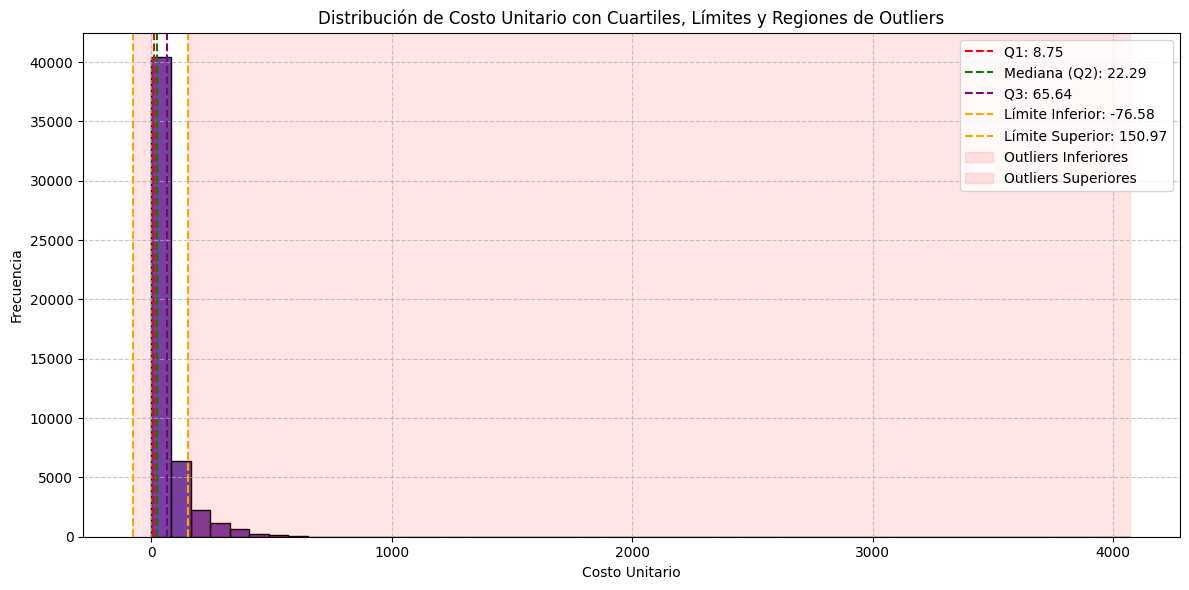

In [48]:
# --- Distribución y Outliers de 'costo_unitario' ---
Q2_costo_unitario = df_borrador['costo_unitario'].median()

# Calcular outliers por debajo y por encima de los límites
outliers_below_lower = df_borrador[df_borrador['costo_unitario'] < lower_bound_costo_unitario]
outliers_above_upper = df_borrador[df_borrador['costo_unitario'] > upper_bound_costo_unitario]

print(f"\nNúmero de outliers por debajo del Límite Inferior: {len(outliers_below_lower)}")
print(f"Número de outliers por encima del Límite Superior: {len(outliers_above_upper)}")

plt.figure(figsize=(12, 6))
sns.histplot(df_borrador['costo_unitario'], bins=50, kde=False, color='indigo')

# Añadir líneas verticales para los cuartiles y límites de outliers
plt.axvline(Q1_costo_unitario, color='red', linestyle='--', label=f'Q1: {Q1_costo_unitario:.2f}')
plt.axvline(Q2_costo_unitario, color='green', linestyle='--', label=f'Mediana (Q2): {Q2_costo_unitario:.2f}')
plt.axvline(Q3_costo_unitario, color='purple', linestyle='--', label=f'Q3: {Q3_costo_unitario:.2f}')
plt.axvline(lower_bound_costo_unitario, color='orange', linestyle='--', label=f'Límite Inferior: {lower_bound_costo_unitario:.2f}')
plt.axvline(upper_bound_costo_unitario, color='orange', linestyle='--', label=f'Límite Superior: {upper_bound_costo_unitario:.2f}')

# Resaltar las áreas de outliers
plt.axvspan(df_borrador['costo_unitario'].min(), lower_bound_costo_unitario, color='red', alpha=0.1, label='Outliers Inferiores')
plt.axvspan(upper_bound_costo_unitario, df_borrador['costo_unitario'].max(), color='red', alpha=0.1, label='Outliers Superiores')

plt.title('Distribución de Costo Unitario con Cuartiles, Límites y Regiones de Outliers')
plt.xlabel('Costo Unitario')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Correlaciòn

### Matriz de Correlación de Variables Numéricas

Para entender las relaciones entre todas las variables numéricas importantes, vamos a calcular y visualizar una matriz de correlación. Esto nos permitirá identificar rápidamente qué variables se mueven juntas (correlación positiva) y cuáles se mueven en direcciones opuestas (correlación negativa), así como la fuerza de estas relaciones.

Número de filas identificadas como outliers (en todas las columnas): 74
Número de filas identificadas como outliers (en sales, precio_unidad y costo_unitario): 74


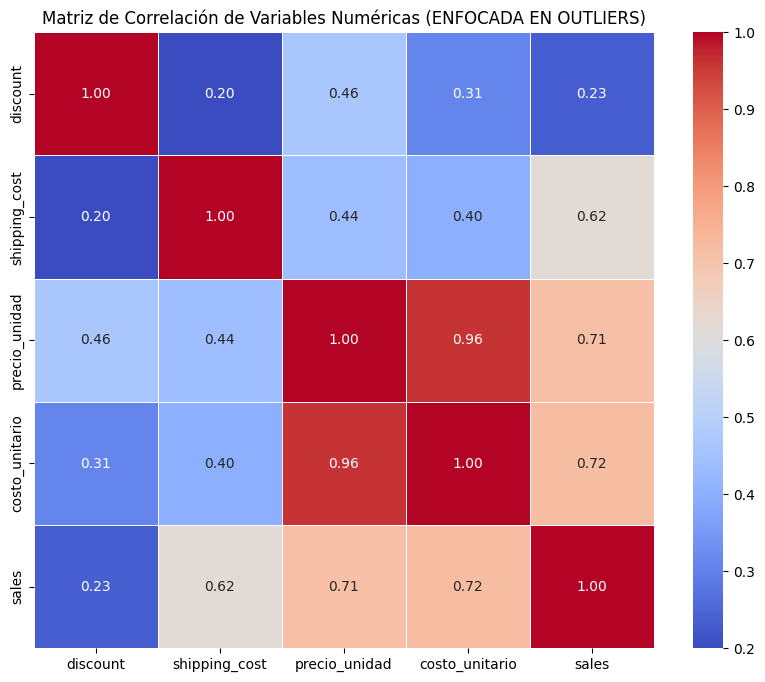

Matriz de Correlación (Enfocada en Outliers):


,discount,shipping_cost,precio_unidad,costo_unitario,sales
discount,1.000000,0.199646,0.464727,0.308308,0.231466
shipping_cost,0.199646,1.000000,0.439696,0.400364,0.618164
precio_unidad,0.464727,0.439696,1.000000,0.961793,0.714219
costo_unitario,0.308308,0.400364,0.961793,1.000000,0.719115
sales,0.231466,0.618164,0.714219,0.719115,1.000000


In [114]:
# Seleccionar solo las columnas numéricas para el cálculo de la correlación
numerical_cols = ['discount', 'shipping_cost', 'precio_unidad', 'costo_unitario', 'sales']

# Definir condiciones individuales de outliers para cada columna numérica
outlier_condition_sales = (df_borrador['sales'] < lower_bound_sales) | (df_borrador['sales'] > upper_bound_sales)
outlier_condition_shipping_cost = (df_borrador['shipping_cost'] < lower_bound_shipping_cost) | (df_borrador['shipping_cost'] > upper_bound_shipping_cost)
outlier_condition_discount = (df_borrador['discount'] < lower_bound_discount) | (df_borrador['discount'] > upper_bound_discount)
outlier_condition_precio_unidad = (df_borrador['precio_unidad'] < lower_bound_precio_unidad) | (df_borrador['precio_unidad'] > upper_bound_precio_unidad)
outlier_condition_costo_unitario = (df_borrador['costo_unitario'] < lower_bound_costo_unitario) | (df_borrador['costo_unitario'] > upper_bound_costo_unitario)

# Combinar todas las condiciones de outliers con AND para encontrar filas que son outliers en TODAS las columnas
combined_outlier_condition = (
    outlier_condition_sales &
    outlier_condition_shipping_cost &
    outlier_condition_discount &
    outlier_condition_precio_unidad &
    outlier_condition_costo_unitario
)

# Filtrar el DataFrame para incluir solo las filas identificadas como outliers
df_outliers = df_borrador[combined_outlier_condition]

print(f"Número de filas identificadas como outliers (en todas las columnas): {len(df_outliers)}")

# Combinar todas las condiciones de outliers con AND para encontrar filas que son outliers en TODAS las columnas
combined_outlier_condition2 = (
    outlier_condition_sales &
    outlier_condition_precio_unidad &
    outlier_condition_costo_unitario
)

# Filtrar el DataFrame para incluir solo las filas identificadas como outliers
df_outliers2 = df_borrador[combined_outlier_condition]

print(f"Número de filas identificadas como outliers (en sales, precio_unidad y costo_unitario): {len(df_outliers2)}")

if not df_outliers.empty:
    correlation_matrix_outliers = df_outliers[numerical_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix_outliers, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Matriz de Correlación de Variables Numéricas (ENFOCADA EN OUTLIERS)')
    plt.show()

    print("Matriz de Correlación (Enfocada en Outliers):")
    display(correlation_matrix_outliers)
else:
    print("No se encontraron suficientes datos de outliers para calcular una matriz de correlación significativa.")

### Eliminación de Outliers Combinados Específicos

Vamos a identificar y eliminar las filas donde las columnas `precio_unidad`, `costo_unitario` y `sales` son *simultáneamente* outliers, ya que el usuario ha solicitado la eliminación explícita de estas transacciones específicas.

In [117]:
# Reutilizamos las condiciones de outliers individuales para las columnas relevantes
# outlier_condition_precio_unidad
# outlier_condition_costo_unitario
# outlier_condition_sales

# Contar cuántas filas cumplen esta condición antes de eliminarlas
num_outliers_to_remove = combined_outlier_condition2.sum()
print(f"Número de filas identificadas como outliers (en precio_unidad, costo_unitario Y sales) para eliminar: {num_outliers_to_remove}")

# Crear un nuevo DataFrame excluyendo las filas que cumplen la condición
df_borrador_cleaned = df_borrador[~combined_outlier_condition2].copy()

print(f"Forma original del DataFrame: {df_borrador.shape}")
print(f"Nueva forma del DataFrame después de eliminar outliers: {df_borrador_cleaned.shape}")
print(f"Se eliminaron {len(df_borrador) - len(df_borrador_cleaned)} filas.")

# Ahora, df_borrador_cleaned es el DataFrame con las filas de outliers eliminadas
# Si deseas usar este DataFrame para análisis posteriores, asegúrate de referenciarlo o reemplazar df_borrador si es el comportamiento deseado.
# Por ahora, mantendremos df_borrador sin cambios para referencia en celdas anteriores, y usaremos df_borrador_cleaned para el análisis posterior si se solicita.

display(df_borrador_cleaned.head())

Número de filas identificadas como outliers (en precio_unidad, costo_unitario Y sales) para eliminar: 3048
Forma original del DataFrame: (51290, 24)
Nueva forma del DataFrame después de eliminar outliers: (48242, 24)
Se eliminaron 3048 filas.


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,204.000000,133.200000,70.800000
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,44.444444,24.748000,19.696444
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,16.500000,7.047500,9.452500
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,30.000000,22.078333,7.921667
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,25.333333,14.306000,11.027333


### Conteo de Outliers por Variable Individual en el DataFrame Depurado (`df_borrador_cleaned`)

Ahora vamos a recalcular y mostrar el número de outliers restantes para cada variable numérica en el DataFrame después de la eliminación de los outliers combinados específicos.

In [116]:
print("\n--- Conteo de Outliers Individuales en df_borrador_cleaned ---\n")

# --- sales ---
outliers_sales_cleaned = df_borrador_cleaned[
    (df_borrador_cleaned['sales'] < lower_bound_sales) |
    (df_borrador_cleaned['sales'] > upper_bound_sales)
]
print(f"Outliers en 'sales': {len(outliers_sales_cleaned)}")

# --- shipping_cost ---
outliers_shipping_cost_cleaned = df_borrador_cleaned[
    (df_borrador_cleaned['shipping_cost'] < lower_bound_shipping_cost) |
    (df_borrador_cleaned['shipping_cost'] > upper_bound_shipping_cost)
]
print(f"Outliers en 'shipping_cost': {len(outliers_shipping_cost_cleaned)}")

# --- discount ---
outliers_discount_cleaned = df_borrador_cleaned[
    (df_borrador_cleaned['discount'] < lower_bound_discount) |
    (df_borrador_cleaned['discount'] > upper_bound_discount)
]
print(f"Outliers en 'discount': {len(outliers_discount_cleaned)}")

# --- precio_unidad ---
outliers_precio_unidad_cleaned = df_borrador_cleaned[
    (df_borrador_cleaned['precio_unidad'] < lower_bound_precio_unidad) |
    (df_borrador_cleaned['precio_unidad'] > upper_bound_precio_unidad)
]
print(f"Outliers en 'precio_unidad': {len(outliers_precio_unidad_cleaned)}")

# --- costo_unitario ---
outliers_costo_unitario_cleaned = df_borrador_cleaned[
    (df_borrador_cleaned['costo_unitario'] < lower_bound_costo_unitario) |
    (df_borrador_cleaned['costo_unitario'] > upper_bound_costo_unitario)
]
print(f"Outliers en 'costo_unitario': {len(outliers_costo_unitario_cleaned)}")

print("\n------------------------------------------------\n")


--- Conteo de Outliers Individuales en df_borrador_cleaned ---

Outliers en 'sales': 2607
Outliers en 'shipping_cost': 3477
Outliers en 'discount': 4067
Outliers en 'precio_unidad': 1984
Outliers en 'costo_unitario': 1903

------------------------------------------------



# Label Encoding

Vamos a aplicar `Label Encoding` a las columnas `ship_mode`, `segment`, `category` y `order_priority`. Esta técnica convierte cada categoría única en un valor numérico, lo cual es útil para modelos que requieren entradas numéricas y para variables con un orden inherente como `order_priority`.

In [120]:
from sklearn.preprocessing import LabelEncoder

In [126]:
# Crear una copia para evitar SettingWithCopyWarning
df_encoded = df_borrador_cleaned.copy()

# Columnas a las que aplicar Label Encoding
columns_to_encode = ['ship_mode', 'order_priority']

# Inicializar y aplicar LabelEncoder a cada columna
for col in columns_to_encode:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])
    print(f"Original values for '{col}': {df_encoded[col].unique()}")
    print(f"Encoded values for '{col}': {df_encoded[col + '_encoded'].unique()}\n")

print("DataFrame con las columnas codificadas:")
display(df_encoded.head())

Original values for 'ship_mode': ['Standard Class' 'Second Class' 'Same Day' 'First Class']
Encoded values for 'ship_mode': [3 2 1 0]

Original values for 'order_priority': ['Medium' 'High' 'Critical' 'Low']
Encoded values for 'order_priority': [3 1 0 2]

DataFrame con las columnas codificadas:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario,ship_mode_encoded,order_priority_encoded
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,204.000000,133.200000,70.800000,3,3
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,44.444444,24.748000,19.696444,3,3
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,16.500000,7.047500,9.452500,2,1
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,30.000000,22.078333,7.921667,2,1
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,25.333333,14.306000,11.027333,3,3


In [128]:
# Corrección de orden jerárquico lógico
df_encoded['order_priority_encoded'] = df_encoded['order_priority'].map({'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3})
df_encoded['ship_mode_encoded'] = df_encoded['ship_mode'].map({'Same Day': 0, 'First Class': 1, 'Second Class': 2, 'Standard Class': 3})


### One-Hot Encoding

Como se discutió previamente, para variables nominales como `segment` y `category`, el Label Encoding puede ser engañoso ya que impone un orden arbitrario. Por ello, aplicaremos One-Hot Encoding, que crea nuevas columnas binarias para cada categoría, evitando la implicación de un orden jerárquico.

In [127]:
# Aplicar One-Hot Encoding a 'segment' y 'category'
df_encoded = pd.get_dummies(df_encoded, columns=['segment', 'category'], prefix=['segment', 'category'], dtype=int)

print("DataFrame con las columnas 'segment' y 'category' codificadas con One-Hot Encoding:")
display(df_encoded.head())

DataFrame con las columnas 'segment' y 'category' codificadas con One-Hot Encoding:


,order_id,order_date,ship_date,ship_mode,customer_name,state,country,market,region,product_id,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,precio_unidad,costo_unitario,margen_unitario,ship_mode_encoded,order_priority_encoded,segment_Consumer,segment_Corporate,segment_Home Office,category_Furniture,category_Office Supplies,category_Technology
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,204.000000,133.200000,70.800000,3,3,1,0,0,0,1,0
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,44.444444,24.748000,19.696444,3,3,1,0,0,0,1,0
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,16.500000,7.047500,9.452500,2,1,1,0,0,0,1,0
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Stockholm,Sweden,EU,North,OFF-PA-10001492,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,30.000000,22.078333,7.921667,2,1,0,0,1,0,1,0
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,25.333333,14.306000,11.027333,3,3,1,0,0,1,0,0


# Predicción de Ganancias

El objetivo es predecir la variable `profit` (ganancias) utilizando un modelo de Regresión Lineal Múltiple (MLR). Las variables predictoras (features) incluirán aspectos como `sales`, `quantity`, `discount`, `shipping_cost`, `precio_unidad`, `costo_unitario`, y las categorías codificadas de `ship_mode`, `order_priority`, `segment` y `category`. Un modelo MLR nos permitirá entender cómo cada una de estas variables contribuye a las ganancias, así como la magnitud y dirección de su impacto.

### Realizar Predicciones

Ahora utilizaremos el modelo `LinearRegression` entrenado para realizar predicciones sobre el conjunto de prueba (`X_test`). Los resultados se almacenarán en la variable `y_pred`.



In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [139]:
# Define features (X) and target (y)
X = df_encoded[['sales', 'quantity', 'discount', 'shipping_cost', 'precio_unidad', 'costo_unitario',
                'ship_mode_encoded', 'order_priority_encoded',
                'segment_Consumer', 'segment_Corporate', 'segment_Home Office',
                'category_Furniture', 'category_Office Supplies', 'category_Technology']]
y = df_encoded['profit']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicciones realizadas exitosamente en el conjunto de prueba.")
display(y_pred[:5])

Predicciones realizadas exitosamente en el conjunto de prueba.


array([ 40.47298132, -46.43054538, -90.95805776,  45.0695891 ,
        73.13547317])

### Evaluar el Rendimiento del Modelo

Vamos a calcular métricas de regresión para evaluar el rendimiento del modelo `LinearRegression` en el conjunto de prueba. Utilizaremos el Error Absoluto Medio (MAE), el Error Cuadrático Medio (MSE), la Raíz del Error Cuadrático Medio (RMSE) y el R-cuadrado.

In [134]:
# Calcular el Error Absoluto Medio (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Error Absoluto Medio (MAE): {mae:.2f}")

# Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")

# Calcular la Raíz del Error Cuadrático Medio (RMSE)
rmse = np.sqrt(mse)
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Calcular el Coeficiente de Determinación (R-cuadrado)
r2 = r2_score(y_test, y_pred)
print(f"R-cuadrado: {r2:.2f}")

Error Absoluto Medio (MAE): 28.73
Error Cuadrático Medio (MSE): 3288.28
Raíz del Error Cuadrático Medio (RMSE): 57.34
R-cuadrado: 0.62


### Visualizar Predicciones vs. Valores Reales

Crearemos un gráfico de dispersión para comparar visualmente los valores de beneficio predichos contra los valores de beneficio reales del conjunto de prueba. Incluiremos una línea diagonal que represente las predicciones perfectas para identificar fácilmente las discrepancias y el ajuste general del modelo.

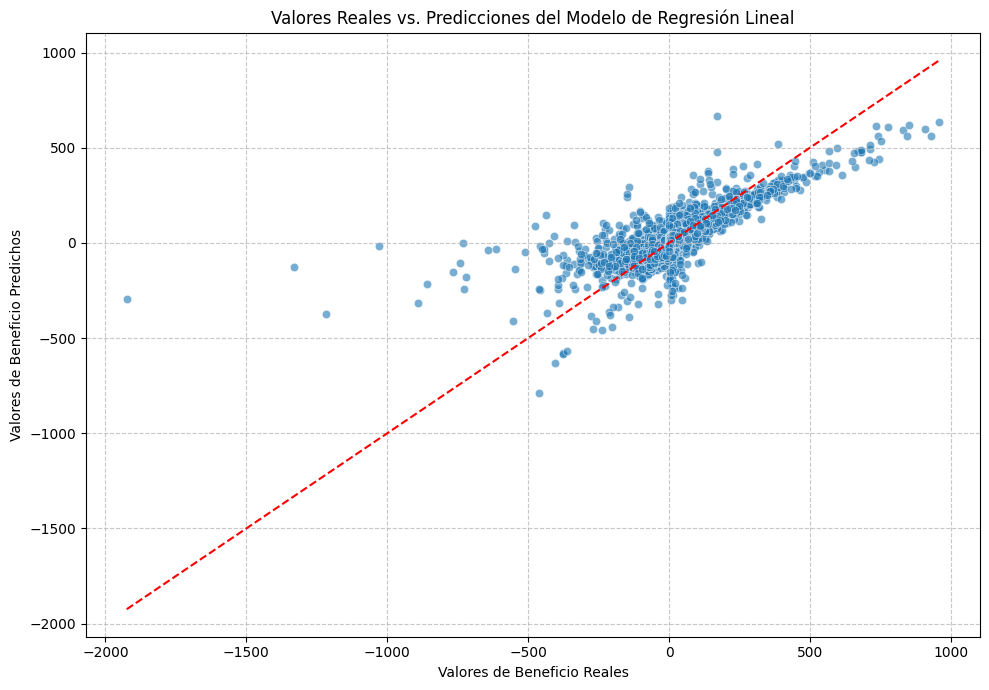

In [135]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Línea de predicción perfecta
plt.xlabel('Valores de Beneficio Reales')
plt.ylabel('Valores de Beneficio Predichos')
plt.title('Valores Reales vs. Predicciones del Modelo de Regresión Lineal')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretar los Coeficientes del Modelo

Los coeficientes de un modelo de regresión lineal representan el cambio promedio en la variable dependiente (en este caso, `profit`) por cada aumento de una unidad en la variable predictora correspondiente, manteniendo todas las demás variables constantes. Un coeficiente positivo indica una relación directa, mientras que uno negativo indica una relación inversa.

In [136]:
print("Coeficientes del Modelo de Regresión Lineal:")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients.sort_values(by='Coefficient', ascending=False))

Coeficientes del Modelo de Regresión Lineal:


,Feature,Coefficient
13,category_Technology,2.514950
12,category_Office Supplies,1.925890
4,precio_unidad,1.279388
6,ship_mode_encoded,1.172206
0,sales,0.343475
9,segment_Corporate,0.249027
8,segment_Consumer,0.163770
10,segment_Home Office,-0.412797
3,shipping_cost,-0.500215
7,order_priority_encoded,-2.446007


### Interpretación de los Coeficientes

Analizando los coeficientes del modelo de Regresión Lineal Múltiple, podemos observar lo siguiente:

*   **`sales` (0.34):** Por cada unidad adicional en `sales`, el `profit` aumenta en 0.34 unidades, manteniendo todas las demás variables constantes. Esto es una relación positiva, como era de esperar, indicando que mayores ventas contribuyen a mayores ganancias.

*   **`discount` (-111.47):** Este es el coeficiente más impactante. Un aumento de una unidad en `discount` (por ejemplo, pasar de 0.1 a 1.1, lo cual es un cambio irreal para un descuento porcentual, pero útil para entender la magnitud) resulta en una disminución muy significativa de `profit` en 111.47 unidades. Esto confirma la observación anterior de que los descuentos altos son perjudiciales para la rentabilidad.

*   **`precio_unidad` (1.28):** Un incremento en el precio unitario se asocia con un aumento en el `profit`, lo cual es intuitivo. Cada aumento de una unidad en `precio_unidad` se asocia con un aumento de 1.28 en `profit`.

*   **`costo_unitario` (1.47):** Sorprendentemente, un aumento en el costo unitario se asocia con un aumento en el `profit`. Esto podría indicar una correlación indirecta donde productos de mayor costo unitario (quizás de mayor calidad o percibidos como tal) se venden a precios más altos, resultando en mayores ganancias a pesar del costo. O podría ser un efecto colineal con `sales` o `precio_unidad`.

*   **`shipping_cost` (-0.50):** Un aumento en el costo de envío tiene un impacto negativo marginal en el `profit`, lo cual es lógico ya que incrementa los gastos.

*   **`quantity` (-7.37):** Un aumento en la cantidad vendida se asocia con una disminución de `profit`. Esto es contraintuitivo y podría sugerir que, para mayores cantidades, se aplican descuentos más agresivos o se incurre en mayores costos de manejo que afectan negativamente la rentabilidad por unidad. También podría ser un indicativo de que las ventas de grandes volúmenes incluyen productos de bajo margen.

*   **`category_Technology` (2.51) y `category_Office Supplies` (1.93):** Estas categorías tienen un impacto positivo en el `profit` en comparación con la categoría base (que sería `Furniture` en este caso, al ser la que no se incluyó en el One-Hot Encoding si asumimos que es la primera alfabéticamente o la que el modelo ha escogido como referencia). `Technology` y `Office Supplies` son las categorías que más contribuyen al beneficio en relación con la base.

*   **`category_Furniture` (-4.44):** Esta categoría tiene un impacto negativo en el `profit` en comparación con las categorías con las que se compara. Podría indicar que los productos de `Furniture` tienen márgenes de ganancia más bajos o costos asociados más altos.

*   **`segment_Corporate` (0.25) y `segment_Consumer` (0.16):** Estos segmentos de clientes tienen un impacto positivo en el `profit` en comparación con el segmento `Home Office` (asumiendo que es la categoría base). Esto sugiere que las ventas a clientes corporativos y consumidores individuales son más rentables.

*   **`segment_Home Office` (-0.41):** Este segmento tiene un impacto negativo en el `profit` en comparación con los otros segmentos, lo que podría indicar que los clientes de `Home Office` tienden a comprar productos con menores márgenes o requieren más costos operativos.

*   **`ship_mode_encoded` (0.01) y `order_priority_encoded` (0.01):** El impacto de estos modos de envío y prioridad de pedido en el `profit` es casi insignificante, lo que sugiere que no son factores determinantes en la rentabilidad del modelo actual.